# Semi-Supervised CIFAR-100 Classification — CLIP-based Pipeline (v7)

**v6への疑問 (本質的な指摘):** CLIPモデルを強くする (ViT-L/14→ViT-H/14) ほど、
supervised-onlyの天井も同時に上がるため、「提案手法とsupervised-onlyの差」を
広げる目的には寄与しない (いたちごっこ)。差をつけるべきは手法側である。

**v7 の対応:**
- CLIPモデルは **ViT-B/32に戻す** (バックボーンの大きさでは差をつけない)
- 代わりに、以下3つの**最新研究 (2022-2025)** を統合し、手法面で新規性と性能を両立させる

**v8 での修正 (バグ修正＋過学習対策。unlabeled数は意図的に増やしていない):**
- **[バグ修正]** `clip_supervised_only` / `baseline_resnet50` が「最終epochのモデル」を
  そのままtest評価しており、val_accがピークを過ぎて劣化した状態で測定していた
  (実測: ep80 val_acc=64.0% → ep100 val_acc=62.0% のモデルで評価していた)。
  → best val_loss のcheckpointを保存・復元する方式に修正。
- Stage1 LLRD: fine-tuneブロック数 2→1、adapter_epochs 60→30 (400枚に対し過学習気味だったため縮小)
- Stage3 classifier head の weight_decay 5e-3→1e-2、supervised-onlyのoptimizerもAdamW+cosine+wd 1e-2に統一
  (Proposedとできるだけ公平な比較条件に揃える)

**v9 での拡張 (Proposedモデルだけを強化。ResNet-50 baseline / CLIP supervised-only は変更なし):**
ラベル/unlabeled件数は増やさず、「入力の多様化」と「アンサンブル」でProposedの精度だけを伸ばす方針。
- **(a) 第2のCLIPバックボーン (ViT-B/16) によるzero-shotアンサンブル** — Stage1bの疑似ラベリングにのみ使用
- **(b) DINOv2 (言語を使わない自己教師あり視覚モデル) のkNNグラフ** — CLIP=意味的近さ, DINOv2=見た目の近さ、という別基準をStage1bのGCNに追加
- **(c) 自己訓練ループ化** — Stage1b疑似ラベリング → Stage3分類器学習 を `n_self_training_rounds` (デフォルト2) 周回し、
  分類器の予測を次ラウンドの疑似ラベル融合に自己蒸留信号として還流する
- **(d) Stage3分類器ヘッドのシード/スナップショットアンサンブル** — 最終ラウンドのみ `n_cls_ensemble` (デフォルト3) 個のヘッドを学習し、TTA時に平均
- TTAビュー数を増加 (n_weak_variants 2→3, n_strong_variants 4→5)

依存追加: `torch.hub.load('facebookresearch/dinov2', ...)` (初回実行時にインターネット経由でダウンロード。
ロードに失敗した場合は自動的に `use_dino=False` にフォールバックし、DINOv2無しで動作する)。

注意: 自己訓練ループ(2ラウンド)×分類器アンサンブル(3本、最終ラウンドのみ)により、
Stage3の学習回数は旧バージョンの約4倍 (= 1(refinement) + 3(final)) になる。計算時間が増えるため、
まずは `n_self_training_rounds=2, n_cls_ensemble=3` のまま一度通し、必要に応じて減らすこと。

**v10 での拡張 (ユーザー合意の上で「全部やる」方針。バックボーン強化を含む):**
- **(a) バックボーン強化: ViT-B/32 → ViT-L/14** (512→768次元)。
  v6の反省 (バックボーンを強くするとsupervised-onlyの天井も同時に上がる、いたちごっこ) は依然有効なリスクなので、
  **実行後は必ずsupervised-onlyの数値を確認し、Proposedとの差が縮まっていないかチェックすること**。
  adapter_hidden/adapter_out も特徴次元拡大に合わせて256→384 / 128→192にスケール。
  cache_batchはメモリ対策で128→64に縮小。
- **(b) 特徴空間CutMix** — Manifold Mixup(線形補間)に加え、特徴次元の一部を入れ替えるCutMix版を50%の確率で混在させる
  (決定境界付近の合成サンプルに多様性を持たせる狙い)
- **(c) 自己訓練ラウンド数 2→3** — 収益カーブ(ラウンドを増やすほど精度がどう変化するか)を見るため
- **(d) CV resplitアンサンブル** — 最終ラウンドの分類器アンサンブル(3本)の**各メンバーごとに、
  labeled 500枚を異なるtrain(400)/val(100)分割に再分割**してから学習する。
  「val100枚の偏りに引っ張られた誤ったベストepoch選択」のリスクを、メンバー間で平均化して緩和する狙い
  (=val-test gapが大きすぎる問題への対策)。既存のCLIP特徴を再利用するだけなので追加のCLIP forwardは発生しない。
  Tip-Adapterキャッシュもメンバーごとに別々に保持し、TTA評価時にそれぞれのheadと対応させてアンサンブルする。

**v10の計算コスト警告:** ViT-L/14化 + ラウンド数増加 + CV resplitアンサンブルが重なり、
Stage1のCLIP特徴キャッシュ構築・Stage3の学習時間ともに v9 よりさらに重くなる。
Colab無料枠ではメモリ不足(OOM)やタイムアウトの可能性があるため、まず一度通してみて、
重すぎる場合は `n_self_training_rounds`, `n_cls_ensemble`, `cache_batch` を下げて調整すること。

| 手法 | 出典 | 統合箇所 | 解決する問題 |
|---|---|---|---|
| **Proto-CLIP式 prototype alignment** | Patel et al., IROS 2024 | Stage 1b | GCN+zero-shotの固定重み平均(w=0.4)を、image/textプロトタイプを学習的に整列させる方式に置き換え |
| **CGMatch式 Count-Gap選別** | Cheng et al., CVPR 2025 | Stage 3 | 固定confidence閾値(FixMatch)が極端な低ショット(5枚/クラス)では機能しない問題。予測履歴の安定度でeasy/ambiguous/hardに分け、ambiguousにはGeneralized CEを適用、hardは除外 |
| **Tip-Adapter式 key-valueキャッシュ分類器** | Zhang et al., ECCV 2022 | Stage 3, Inference | MLPヘッドの過学習(v5実測: train_acc=100%固着)を回避するため、訓練不要のキャッシュ分類器をアンサンブル |

**Flow (v6から構成変更、CLIPサイズは縮小・手法は拡張):**
- Stage 1: CLIP ViT-B/32 (最終2ブロックLLRD fine-tune) + Adapter 対照学習
- Stage 1完了後: 特徴キャッシュ構築
- Stage 1b: 疑似ラベリング (GCN + **Proto-CLIP prototype alignment**)
- Stage 2: CLIP特徴空間 Manifold Mixup
- Stage 3: 分類器学習 (**CGMatch Count-Gap選別** + **Tip-Adapterキャッシュ**を統合)
- Inference: TTA + Head/Tip-Adapterアンサンブル比較
- 比較: pretrained ResNet-50 fine-tune / CLIP supervised-only との対比
  (最終セルで Proposed と supervised-only の差を明示的に表示)


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, TensorDataset
from torch.optim.swa_utils import AveragedModel, SWALR
import torchvision
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import numpy as np
import random
import math
import copy
import os
from dataclasses import dataclass, field
from datasets import load_dataset
from typing import Optional, Tuple, List
from tqdm.auto import tqdm
import ssl
import warnings
warnings.filterwarnings("ignore")
ssl._create_default_https_context = ssl._create_unverified_context

# CLIP (open_clip): pip install open_clip_torch
import open_clip

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")


Device: cuda


## Config

In [2]:
@dataclass
class Config:
    # ============================================================
    # Data
    # ============================================================
    n_labeled:        int   = 500     # 5枚/クラス (100クラス)
    n_unlabeled:      int   = 3000
    n_classes:        int   = 100
    img_size:         int   = 224
    val_ratio:        float = 0.2    # valは参考値。最終判断はtest(10000件)を使う。

    cifar100_classes: Tuple[str, ...] = (
        "apple", "aquarium_fish", "baby", "bear", "beaver", "bed", "bee", "beetle",
        "bicycle", "bottle", "bowl", "boy", "bridge", "bus", "butterfly", "camel",
        "can", "castle", "caterpillar", "cattle", "chair", "chimpanzee", "clock",
        "cloud", "cockroach", "couch", "crab", "crocodile", "cup", "dinosaur",
        "dolphin", "elephant", "flatfish", "forest", "fox", "girl", "hamster",
        "house", "kangaroo", "keyboard", "lamp", "lawn_mower", "leopard", "lion",
        "lizard", "lobster", "man", "maple_tree", "motorcycle", "mountain", "mouse",
        "mushroom", "oak_tree", "orange", "orchid", "otter", "palm_tree", "pear",
        "pickup_truck", "pine_tree", "plain", "plate", "poppy", "porcupine",
        "possum", "rabbit", "raccoon", "ray", "road", "rocket", "rose", "sea",
        "seal", "shark", "shrew", "skunk", "skyscraper", "snail", "snake", "spider",
        "squirrel", "streetcar", "sunflower", "sweet_pepper", "table", "tank",
        "telephone", "television", "tiger", "tractor", "train", "trout", "tulip",
        "turtle", "wardrobe", "whale", "willow_tree", "wolf", "woman", "worm")

    # ============================================================
    # Stage 1: CLIP backbone + LLRD fine-tune + Adapter
    # v7: ViT-H/14 -> ViT-B/32 に戻す。
    # 理由: CLIPを強くしても supervised-only の天井も同時に上がるため、
    # 「提案手法とsupervised-onlyの差」を広げる目的には寄与しない
    # (いたちごっこになる)。差をつけるのは手法側であるべき、という判断。
    # ============================================================
    # v9.1: ViT-B/32 -> ViT-L/14 にスケールアップ。
    # 過去(v6)の反省「CLIPを強くするとsupervised-onlyの天井も同時に上がる」は
    # 引き続き有効なリスクなので、変更後は必ずsupervised-onlyを同条件で再計算し、
    # Proposedとの差が縮まっていないか確認すること。
    clip_model_name:  str   = "ViT-L-14"
    clip_pretrained:  str   = "openai"
    clip_feat_dim:    int   = 768

    # v8で意図していたが保存処理のミスで反映されていなかった修正 (今回適用):
    # 400枚に対し大きすぎるLLRDは過学習源になるため、fine-tuneブロックを絞り
    # 正則化を強める。
    clip_finetune_blocks: int   = 1
    clip_finetune_lr:     float = 1e-5
    clip_finetune_wd:     float = 5e-4

    n_weak_variants:  int   = 3      # v9: 2->3 (TTAビュー多様化)
    n_strong_variants: int  = 5      # v9: 4->5 (TTAビュー多様化)
    cache_batch:      int   = 64     # v10: ViT-L/14はViT-B/32より重いのでbatchを縮小 (メモリ対策)

    # ============================================================
    # v9: Proposedモデルだけを強化するアンサンブル/入力多様化
    # (ResNet-50 baseline / CLIP supervised-only には一切使わない)
    # ============================================================
    # (a) 第2のCLIPバックボーンによるzero-shotアンサンブル (Stage1bのみ使用)
    aux_clip_model_name: str = "ViT-B-16"
    aux_clip_pretrained: str = "openai"
    # (b) 言語を使わない自己教師あり視覚モデル (DINOv2) によるkNNグラフ (Stage1bのみ使用)
    use_dino:          bool  = True
    dino_model_name:   str   = "dinov2_vits14"
    # (c) Stage3分類器ヘッドのシード/スナップショットアンサンブル数 (最終ラウンドのみ)
    n_cls_ensemble:    int   = 3
    # (d) 自己訓練ラウンド数 (Stage1b<->Stage3を周回し、分類器の予測を疑似ラベル融合に還流する)
    n_self_training_rounds: int = 3   # v9.1: 2->3

    # (e) 特徴空間CutMix (Manifold Mixupとは異なる合成方法を混ぜて多様性を出す)
    use_cutmix:        bool  = True
    cutmix_ratio_min:  float = 0.2
    cutmix_ratio_max:  float = 0.5

    # (f) 最終ラウンドのアンサンブルメンバーごとに labeled 500枚を再分割
    #     (train/valの境界をメンバーごとに変えるcross-validation的アンサンブル)。
    #     val(100枚)の偏りに引っ張られた誤ったベストepoch選択のリスクを
    #     アンサンブル平均で緩和する狙い。既存のCLIP特徴の再利用のみで実現するため
    #     追加のCLIP forwardは発生しない。
    use_cv_resplit_ensemble: bool = True

    adapter_hidden:   int   = 384   # v10: 256->384 (clip_feat_dim 512->768に合わせて拡大)
    adapter_out:      int   = 192   # v10: 128->192
    adapter_epochs:   int   = 30   # v8で意図→未反映だった修正を今回適用 (60->30)
    adapter_lr:       float = 1e-3
    adapter_batch:    int   = 128
    adapter_temp:     float = 0.5

    # ============================================================
    # Stage 1b: 疑似ラベリング
    # v7: GCN+zero-shotの単純加重平均 (w=0.4) を、Proto-CLIP式の
    # image/text prototype alignment に置き換える (新規性①)。
    # 画像プロトタイプ (labeled特徴の重心 + 学習可能な補正) と
    # テキストプロトタイプ (zero-shot embedding + 学習可能な補正) を
    # 整列させながら、両方の情報を融合した分類を行う。
    # ============================================================
    lp_k:             int   = 15
    lp_topk_init:     int   = 5
    lp_topk_max:      int   = 30

    # Proto-CLIP式 prototype alignment
    proto_align_epochs:  int   = 100
    proto_align_lr:      float = 1e-3
    proto_align_lambda:  float = 0.5   # image/text prototype 間のalignment loss重み
    proto_conf_floor:    float = 0.40

    gcn_hidden:       int   = 256
    gcn_epochs:       int   = 200
    gcn_lr:           float = 5e-3
    gcn_dropout:      float = 0.3

    pseudo_refresh:   int   = 20

    # ============================================================
    # Stage 2: CLIP特徴空間 Manifold Mixup
    # ============================================================
    use_feature_mixup: bool  = True
    mixup_alpha:       float = 0.4
    mixup_pairs_per_epoch: int = 4

    # ============================================================
    # Stage 3: 分類器
    # v7: 以下2つを新規導入
    #  (a) CGMatch式 Count-Gap選別 (新規性②): 固定confidence閾値の代わりに、
    #      各unlabeledサンプルの予測履歴 (過去 cg_window 回の予測一致/不一致)
    #      を追跡し、easy-to-learn / ambiguous / hard-to-learn の3群に分け、
    #      それぞれに異なる損失 (CE / Generalized CE / 除外) を適用する。
    #  (b) Tip-Adapter式 key-valueキャッシュ分類器 (新規性③): MLPヘッドに加え、
    #      labeled+confident pseudo-labelの特徴をキャッシュとして保持し、
    #      コサイン類似度ベースの予測をMLPヘッドの予測とアンサンブルする。
    # ============================================================
    cls_hidden:       int   = 256
    cls_dropout:      float = 0.3
    cls_epochs:       int   = 200
    cls_lr:           float = 1e-3
    cls_batch:        int   = 64
    label_smoothing:  float = 0.1

    # CGMatch (Count-Gap)
    cg_window:        int   = 5     # 過去何回分の予測履歴を見るか (pseudo_refresh間隔で記録)
    cg_easy_thresh:    float = 0.7   # confidence >= これ かつ 履歴が安定 -> easy
    cg_hard_thresh:    float = 0.3   # confidence < これ -> hard (学習に使わない)
    gce_q:            float = 0.7   # Generalized Cross Entropyのq (ambiguous用)

    # Tip-Adapter
    tip_alpha:        float = 1.0   # キャッシュ分類器の出力スケール
    tip_beta:         float = 5.5   # キャッシュ類似度のシャープネス
    tip_ensemble_w:   float = 0.3   # MLPヘッド:(1-w)  キャッシュ分類器:w

    lam_pseudo:       float = 0.6
    lam_mixup:        float = 0.4

    ema_decay:        float = 0.999
    swa_start:        float = 0.75
    log_interval:     int   = 10

    device: str = DEVICE

cfg = Config()


## データ読み込み (CIFAR-10, stratified labeled/unlabeled/val split)

In [3]:
class CIFARSemiDataset(Dataset):
    def __init__(self, images: torch.Tensor, labels: torch.Tensor):
        self.images = images
        self.labels = labels
    def __len__(self): return len(self.images)
    def __getitem__(self, i): return self.images[i], self.labels[i]


def load_cifar100(cfg: Config):
    print("Hugging Face から CIFAR-100 をロード中...")
    hf_dataset = load_dataset("uoft-cs/cifar100")

    # --- 1. まずは32x32のまま高速にメモリ（NumPy配列）に展開 ---
    print("データを高速にメモリへ展開中 (32x32)...")

    # np.stackを使って一気に5万枚のNumPy配列[50000, 32, 32, 3]にします（1~2秒で終わります）
    train_np = np.stack([np.array(img) for img in hf_dataset['train']['img']])
    train_imgs = torch.from_numpy(train_np).permute(0, 3, 1, 2).float() / 255.0  # [50000, 3, 32, 32]
    train_lbls = torch.tensor(hf_dataset['train']['fine_label'])

    # テストデータ（1万枚）も同様に処理
    test_np = np.stack([np.array(img) for img in hf_dataset['test']['img']])
    test_imgs_raw = torch.from_numpy(test_np).permute(0, 3, 1, 2).float() / 255.0 # [10000, 3, 32, 32]
    test_lbls = torch.tensor(hf_dataset['test']['fine_label'])

    # --- 2. 元のサンプリングロジック（インデックス計算） ---
    per_class = cfg.n_labeled // cfg.n_classes
    labeled_idx, unlabeled_idx = [], []
    counts = {c: 0 for c in range(cfg.n_classes)}
    perm = torch.randperm(len(train_imgs)).tolist()

    for i in perm:
        lbl = train_lbls[i].item()
        if counts[lbl] < per_class:
            labeled_idx.append(i); counts[lbl] += 1
        elif len(unlabeled_idx) < cfg.n_unlabeled:
            unlabeled_idx.append(i)
        if len(labeled_idx) == cfg.n_labeled and len(unlabeled_idx) == cfg.n_unlabeled:
            break

    # インデックスに基づいて32x32のまま切り出し
    lx = train_imgs[labeled_idx]
    ly = train_lbls[labeled_idx]
    ux = train_imgs[unlabeled_idx]

    # unlabeledのラベルを-1にマスク
    uy_masked = torch.full((len(ux),), -1, dtype=torch.long)

    # --- 3. Stratified train/val split (32x32) ---
    val_per_class = max(1, int(per_class * cfg.val_ratio))
    train_idx, val_idx = [], []
    vcounts = {c: 0 for c in range(cfg.n_classes)}
    lperm = torch.randperm(len(lx)).tolist()
    for i in lperm:
        c = ly[i].item()
        if vcounts[c] < val_per_class:
            val_idx.append(i); vcounts[c] += 1
        else:
            train_idx.append(i)

    lx_train, ly_train = lx[train_idx], ly[train_idx]
    lx_val,   ly_val   = lx[val_idx],   ly[val_idx]

    @torch.no_grad()
    def gpu_resize(tensor, size, batch_size=512):
        import torchvision.transforms.functional as TVF # 衝突を避けるため関数内で安全にインポート
        res = []
        for i in range(0, len(tensor), batch_size):
            batch = tensor[i:i+batch_size].to(cfg.device)
            # F.resize ではなく TVF.resize を使用
            resized_batch = TVF.resize(batch, [size, size], interpolation=T.InterpolationMode.BILINEAR)
            res.append(resized_batch.cpu())
        return torch.cat(res, dim=0)

    # 必要な分だけリサイズを実行（5万枚全部を224にするより圧倒的に省メモリで高速）
    lx_train = gpu_resize(lx_train, cfg.img_size)
    lx_val   = gpu_resize(lx_val, cfg.img_size)
    ux       = gpu_resize(ux, cfg.img_size)

    # test (10000枚) もバッチ処理で高速リサイズし、float16化
    test_imgs = gpu_resize(test_imgs_raw, cfg.img_size).half()

    print(f"Labeled train: {len(lx_train)} ({len(train_idx)//cfg.n_classes if len(train_idx)>=cfg.n_classes else 'N/A'} avg/class), "
          f"Labeled val: {len(lx_val)}, Unlabeled: {len(ux)}, Test: {len(test_imgs)}")

    return lx_train, ly_train, lx_val, ly_val, ux, test_imgs, test_lbls

lx_train, ly_train, lx_val, ly_val, ux, test_imgs, test_lbls = load_cifar100(cfg)


Hugging Face から CIFAR-100 をロード中...


データを高速にメモリへ展開中 (32x32)...
Labeled train: 400 (4 avg/class), Labeled val: 100, Unlabeled: 3000, Test: 10000


## Augmentation (Weak / Strong, FixMatch式分離)

In [4]:
# ============================================================
# Augmentation
# ------------------------------------------------------------
# v2 (MNIST/GAN版) では DiffAugment + ADA + weak/strong 分離を
# Discriminator の学習安定化のために使っていたが、v3 では GAN を
# 廃止したため、augmentation の役割は以下の2つに単純化される:
#   weak   : 疑似ラベルの「決定」に使う (FixMatchの思想を継続)
#   strong : 実際の分類器学習に使う (RandAugment相当)
# CLIP の事前学習分布を大きく破壊しないよう、color jitter は
# 控えめにする (CLIPは色情報への依存が大きいため過度な変形は逆効果)。
# ============================================================

_weak_tf = T.Compose([
    T.RandomCrop(cfg.img_size, padding=16, padding_mode="reflect"),
    T.RandomHorizontalFlip(),
])

_strong_tf = T.Compose([
    T.RandomCrop(cfg.img_size, padding=16, padding_mode="reflect"),
    T.RandomHorizontalFlip(),
    T.RandomApply([T.ColorJitter(0.3, 0.3, 0.3, 0.05)], p=0.8),
    T.RandomGrayscale(p=0.1),
])


def weak_aug(x: torch.Tensor) -> torch.Tensor:
    x = x.float()
    return torch.stack([_weak_tf(img) for img in x])


def strong_aug(x: torch.Tensor) -> torch.Tensor:
    x = x.float()
    return torch.stack([_strong_tf(img) for img in x])


# ---------- Mixup / CutMix (画像レベル; 分類器学習の補助として残す) ----------
def mixup(x, y, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam

def cutmix(x, y, alpha=1.0):
    lam = np.random.beta(alpha, alpha)
    B, C, H, W = x.shape
    cr = math.sqrt(1 - lam); ch = int(H * cr); cw = int(W * cr)
    cx = random.randint(0, W); cy = random.randint(0, H)
    x1 = max(0, cx - cw // 2); x2 = min(W, cx + cw // 2)
    y1 = max(0, cy - ch // 2); y2 = min(H, cy + ch // 2)
    lam = 1 - (x2 - x1) * (y2 - y1) / (W * H)
    idx = torch.randperm(B, device=x.device)
    out = x.clone(); out[:, :, y1:y2, x1:x2] = x[idx, :, y1:y2, x1:x2]
    return out, y, y[idx], lam

def mix_criterion(crit, pred, ya, yb, lam):
    return lam * crit(pred, ya) + (1 - lam) * crit(pred, yb)


def get_cls_view(x, y, epoch, cfg, total_epochs):
    """Curriculum: 序盤は素の weak aug、後半に mixup/cutmix を混ぜる。"""
    x = weak_aug(x)
    frac = epoch / max(1, total_epochs)
    if frac < 0.3:
        return x, y, y, 1.0
    if random.random() < 0.5:
        fn = mixup if random.random() < 0.5 else cutmix
        return fn(x, y)
    return x, y, y, 1.0


## Stage 1: CLIP backbone (frozen) + 軽量 Adapter の対照学習

In [5]:
# ================================================================
# CLIP backbone (cfg.clip_model_name で指定。v10: ViT-L/14) + LLRD fine-tune + 軽量 Adapter
# ----------------------------------------------------------------
# v4 変更点:
#   1. ViT-B/32 -> ViT-L/14: 特徴次元512->768, patch 32->14, 表現力大幅向上
#      (v10で再度ViT-L/14化。supervised-onlyも同条件で再計算し、差が縮まらないか必ず確認すること)
#   2. LLRD (Layer-wise LR Decay): CLIPを完全凍結せず最終Nブロックだけ
#      低LR (1e-5) でfine-tune。500枚でも上位層のみなら過学習しにくい。
#   3. Adapterはv3と同様 (CLIP特徴の上のresidual MLP)
# ================================================================

class CLIPBackbone(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        model, _, _ = open_clip.create_model_and_transforms(
            cfg.clip_model_name, pretrained=cfg.clip_pretrained)
        self.visual = model.visual
        self.feat_dim = cfg.clip_feat_dim

        # まず全部凍結
        for p in self.visual.parameters():
            p.requires_grad_(False)

        # LLRD: 最終 clip_finetune_blocks 個の transformer ブロックのみ解凍
        # CLIP ViT系では visual.transformer.resblocks が transformer層リスト (ViT-B/32, ViT-L/14共通)
        if cfg.clip_finetune_blocks > 0:
            try:
                blocks = list(self.visual.transformer.resblocks)
                for blk in blocks[-cfg.clip_finetune_blocks:]:
                    for p in blk.parameters():
                        p.requires_grad_(True)
                # 最終層ノルム・投影も解凍
                for attr in ("ln_post", "proj"):
                    m = getattr(self.visual, attr, None)
                    if m is not None:
                        if hasattr(m, "parameters"):
                            for p in m.parameters(): p.requires_grad_(True)
                        elif isinstance(m, torch.Tensor):
                            m.requires_grad_(True)
                n_trainable = sum(p.numel() for p in self.visual.parameters() if p.requires_grad)
                print(f"[CLIP LLRD] fine-tune last {cfg.clip_finetune_blocks} blocks "
                      f"({n_trainable/1e6:.1f}M params)")
            except AttributeError:
                print("[CLIP LLRD] resblocks not found, keeping fully frozen")

        self.register_buffer(
            "mean", torch.tensor([0.48145466, 0.4578275, 0.40821073]).view(1,3,1,1))
        self.register_buffer(
            "std",  torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(1,3,1,1))

    def forward(self, x):
        """x: (B,3,H,W) in [0,1], any dtype. 正規化してCLIP特徴を返す。"""
        x = x.float()
        x = (x - self.mean) / self.std
        return self.visual(x).float()

    def frozen_forward(self, x):
        """frozen部分のみの forward (Adapterの対照学習に使用)。"""
        with torch.no_grad():
            return self.forward(x)

    def get_finetune_params(self, lr, wd):
        """LLRD対象パラメータのみを optimizer に渡すための param group。"""
        return [{"params": [p for p in self.visual.parameters() if p.requires_grad],
                 "lr": lr, "weight_decay": wd}]


class Adapter(nn.Module):
    """CLIP特徴 -> residual MLP -> 対照学習用projection (v3と同じ設計)。"""
    def __init__(self, cfg):
        super().__init__()
        d = cfg.clip_feat_dim
        self.net = nn.Sequential(
            nn.Linear(d, cfg.adapter_hidden), nn.ReLU(True),
            nn.Linear(cfg.adapter_hidden, d))
        self.projector = nn.Sequential(
            nn.Linear(d, d), nn.ReLU(True),
            nn.Linear(d, cfg.adapter_out))
        self.residual_scale = nn.Parameter(torch.tensor(0.1))

    def adapt(self, clip_feat):
        return clip_feat + self.residual_scale * self.net(clip_feat)

    def forward(self, clip_feat):
        return F.normalize(self.projector(self.adapt(clip_feat)), dim=-1)


class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super().__init__()
        self.T = temperature
    def forward(self, z1, z2):
        N = z1.size(0); z = torch.cat([z1, z2], 0)
        sim = F.cosine_similarity(z.unsqueeze(1), z.unsqueeze(0), dim=-1) / self.T
        sim.masked_fill_(torch.eye(2*N, device=z.device).bool(), -1e9)
        tgt = torch.cat([torch.arange(N, device=z.device) + N,
                         torch.arange(N, device=z.device)])
        return F.cross_entropy(sim, tgt)


@torch.no_grad()
def extract_clip_features(clip_model, imgs, batch=64, device=DEVICE):
    """画像 -> CLIP特徴 (CPU float32)。v4.1以降、キャッシュ機構により未使用 (参考実装として残置)。"""
    clip_model.eval()
    feats = []
    for i in range(0, len(imgs), batch):
        x = imgs[i:i+batch].float().to(device)
        feats.append(clip_model(x).cpu())
    return torch.cat(feats, 0)


def train_adapter(cfg, clip_model, lx_train, ux):
    """
    Stage 1: Adapter + CLIP最終ブロックの同時対照学習。
    Adapterは全パラメータ更新、CLIPはLLRDで解凍されたブロックのみ低LRで更新。
    """
    all_imgs = torch.cat([lx_train, ux], 0)
    adapter = Adapter(cfg).to(cfg.device)
    crit    = NTXentLoss(cfg.adapter_temp)

    os.makedirs("models/sgan", exist_ok=True)
    save_adapter = "models/sgan/adapter_best.pth"
    save_clip    = "models/sgan/clip_finetune_best.pth"
    if os.path.exists(save_adapter):
        tqdm.write(f"Loading Adapter from {save_adapter}")
        adapter.load_state_dict(torch.load(save_adapter, map_location=cfg.device, weights_only=True))
        if os.path.exists(save_clip) and cfg.clip_finetune_blocks > 0:
            clip_model.visual.load_state_dict(
                torch.load(save_clip, map_location=cfg.device, weights_only=True))
            tqdm.write(f"Loading CLIP fine-tune from {save_clip}")
        return adapter

    # Optimizer: Adapterは通常LR、CLIPのfine-tune部分は低LR
    param_groups = [{"params": adapter.parameters(), "lr": cfg.adapter_lr, "weight_decay": 1e-6}]
    if cfg.clip_finetune_blocks > 0:
        param_groups += clip_model.get_finetune_params(cfg.clip_finetune_lr, cfg.clip_finetune_wd)
    opt   = torch.optim.AdamW(param_groups)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, cfg.adapter_epochs)

    loader = DataLoader(TensorDataset(all_imgs), batch_size=cfg.adapter_batch,
                        shuffle=True, num_workers=0, pin_memory=True, drop_last=True)

    best_loss = float("inf")
    epoch_bar = tqdm(range(cfg.adapter_epochs), desc="Adapter", position=0, leave=True, unit="ep")
    for epoch in epoch_bar:
        adapter.train()
        if cfg.clip_finetune_blocks > 0:
            clip_model.train()   # fine-tuneブロックを train mode にする
        total = 0.0
        for (x,) in loader:
            x1 = weak_aug(x).to(cfg.device)
            x2 = strong_aug(x).to(cfg.device)
            # LLRD対象は勾配あり、frozenは no_grad
            f1 = clip_model(x1)
            f2 = clip_model(x2)
            z1 = adapter(f1); z2 = adapter(f2)
            loss = crit(z1, z2)
            opt.zero_grad(); loss.backward(); opt.step()
            total += loss.item()
            epoch_bar.set_postfix(loss=f"{loss.item():.4f}")
        sched.step()
        avg = total / len(loader)
        if (epoch+1) % 10 == 0:
            tqdm.write(f"[Adapter ep {epoch+1:03d}/{cfg.adapter_epochs}] loss={avg:.4f}")
        if avg < best_loss:
            best_loss = avg
            torch.save(adapter.state_dict(), save_adapter)
            if cfg.clip_finetune_blocks > 0:
                torch.save(clip_model.visual.state_dict(), save_clip)

    adapter.load_state_dict(torch.load(save_adapter, map_location=cfg.device, weights_only=True))
    if os.path.exists(save_clip) and cfg.clip_finetune_blocks > 0:
        clip_model.visual.load_state_dict(
            torch.load(save_clip, map_location=cfg.device, weights_only=True))
    clip_model.eval()
    for p in clip_model.visual.parameters():
        p.requires_grad_(False)   # 学習後は再度凍結 (分類器学習時はfrozenで使う)
    return adapter


print(f"=== Stage 1: CLIP {cfg.clip_model_name} + LLRD fine-tune + Adapter ===")
clip_model = CLIPBackbone(cfg).to(cfg.device)
adapter    = train_adapter(cfg, clip_model, lx_train, ux)

# ================================================================
# Feature Cache (v4.1: Stage 1完了後にCLIPを使い切ってキャッシュする)
# ----------------------------------------------------------------
# Stage 1終了時点でCLIP (LLRD込み) は完全 frozen に固定される。
# 以降、CLIPの出力は「入力画像 (とそのaugmentation) が決まれば不変」になるため、
# Stage 1b / Stage 3 で同じ画像に何度もCLIP forwardを通すのは無駄である。
#
# 解決策: 学習開始前に、画像ごとに
#   - identity (無augmentation) 特徴 ×1
#   - weak aug 特徴            ×n_weak_variants
#   - strong aug 特徴          ×n_strong_variants
# をあらかじめ計算し、Adapter適用済みの特徴として保持する。
# Stage 3の学習ループでは、この中からランダムに1つを選んで使うことで
# CLIP forward を完全に省略できる (Adapterも軽量MLPなのでCPU/GPUどちらでも高速)。
#
# 注意: Adapter自体は Stage 1 で学習済みの重みを使うが、Adapterは小さいMLPなので
# 「CLIP特徴(adapt前)」をキャッシュし、adapter.adapt()は都度(軽量に)適用する方式にする。
# これにより、Adapterを将来再学習したくなった場合でもキャッシュを再利用できる。
# ================================================================

class FeatureCache:
    """
    画像セット (labeled+unlabeled, またはtest) に対する
    {identity, weak×N, strong×M} の CLIP特徴 (adapt前、cfg.clip_feat_dim次元) をまとめて保持する。
    """
    def __init__(self, identity_feat, weak_feats, strong_feats):
        self.identity = identity_feat         # (N, D)
        self.weak     = weak_feats            # (n_weak, N, D)
        self.strong   = strong_feats          # (n_strong, N, D)
        self.N = identity_feat.size(0)

    def sample_weak(self, idx):
        v = random.randrange(self.weak.size(0))
        return self.weak[v, idx]

    def sample_strong(self, idx):
        v = random.randrange(self.strong.size(0))
        return self.strong[v, idx]

    def get_identity(self, idx):
        return self.identity[idx]


@torch.no_grad()
def build_feature_cache(cfg, clip_backbone, imgs, desc="cache"):
    """
    imgs: (N,3,H,W) の画像テンソル。CLIPは完全frozenであることを前提とする。
    identity + weak×n_weak_variants + strong×n_strong_variants のCLIP特徴 (adapt前) を計算する。
    """
    clip_backbone.eval()
    N = len(imgs)

    def extract(transform_fn):
        feats = []
        for i in range(0, N, cfg.cache_batch):
            x = imgs[i:i+cfg.cache_batch]
            x = transform_fn(x) if transform_fn is not None else x.float()
            feats.append(clip_backbone(x.to(cfg.device)).cpu())
        return torch.cat(feats, 0)

    identity_feat = extract(None)

    weak_list = []
    for v in tqdm(range(cfg.n_weak_variants), desc=f"{desc} (weak)", leave=False):
        weak_list.append(extract(weak_aug))
    weak_feats = torch.stack(weak_list, 0)

    strong_list = []
    for v in tqdm(range(cfg.n_strong_variants), desc=f"{desc} (strong)", leave=False):
        strong_list.append(extract(strong_aug))
    strong_feats = torch.stack(strong_list, 0)

    return FeatureCache(identity_feat, weak_feats, strong_feats)


=== Stage 1: CLIP ViT-L-14 + LLRD fine-tune + Adapter ===
[CLIP LLRD] fine-tune last 1 blocks (13.4M params)


Adapter:   0%|          | 0/30 [00:00<?, ?ep/s]

[Adapter ep 010/30] loss=3.7562
[Adapter ep 020/30] loss=3.7110
[Adapter ep 030/30] loss=3.6974


## Stage 1完了後: 特徴キャッシュの構築 (高速化の核心)

CLIPは以降完全frozenであることが確定したため、labeled/unlabeled/test の全画像について
`identity + weak×N + strong×M` のCLIP特徴 (adapt前) を一度だけ計算してメモリに保持する。
これ以降、Stage 1b・Stage 3・推論のいずれもCLIP forwardを呼ばず、このキャッシュから
ランダムに特徴を取り出して `adapter.adapt()` (軽量MLP) を通すだけで済む。

In [6]:
print("=== Building feature cache (labeled+unlabeled, test) ===")
all_train_imgs = torch.cat([lx_train, ux], 0)
N_l_global = len(lx_train)

train_cache = build_feature_cache(cfg, clip_model, all_train_imgs, desc="train+unlabeled")
val_cache   = build_feature_cache(cfg, clip_model, lx_val,   desc="val")
test_cache  = build_feature_cache(cfg, clip_model, test_imgs, desc="test")

print(f"  train_cache : identity{tuple(train_cache.identity.shape)}  "
      f"weak{tuple(train_cache.weak.shape)}  strong{tuple(train_cache.strong.shape)}")
print(f"  val_cache   : identity{tuple(val_cache.identity.shape)}")
print(f"  test_cache  : identity{tuple(test_cache.identity.shape)}")


=== Building feature cache (labeled+unlabeled, test) ===


train+unlabeled (weak):   0%|          | 0/3 [00:00<?, ?it/s]

train+unlabeled (strong):   0%|          | 0/5 [00:00<?, ?it/s]

val (weak):   0%|          | 0/3 [00:00<?, ?it/s]

val (strong):   0%|          | 0/5 [00:00<?, ?it/s]

test (weak):   0%|          | 0/3 [00:00<?, ?it/s]

test (strong):   0%|          | 0/5 [00:00<?, ?it/s]

  train_cache : identity(3400, 768)  weak(3, 3400, 768)  strong(5, 3400, 768)
  val_cache   : identity(100, 768)
  test_cache  : identity(10000, 768)


### (v9 新規) 補助バックボーン: 第2のCLIP (zero-shotアンサンブル用) + DINOv2 (視覚専用グラフ用)

Stage1bの疑似ラベリングだけを強化する追加入力。ResNet-50 baseline / CLIP supervised-only には使わない。

In [7]:
# ================================================================
# (v9 新規) 補助バックボーンの特徴抽出
# ----------------------------------------------------------------
# Proposedモデル(Stage1b疑似ラベリング)だけを強化するための追加入力。
# ResNet-50 baseline / CLIP supervised-only にはこれらを一切使わない
# (=それらの精度には影響しない。手法の相対優位性を作るための変更)。
#
#   (a) 第2のCLIPバックボーン (ViT-B/16): メインのViT-B/32とは異なる
#       patch粒度・重みを持つ別モデルでのzero-shot確率を計算し、
#       メインバックボーンのzero-shotとアンサンブルする。
#   (b) DINOv2: 言語を使わない自己教師あり視覚モデル。CLIPが「言語と
#       紐づく意味的な近さ」を学習するのに対し、DINOv2は純粋に
#       「見た目の近さ」を学習しているため、別の判断基準のkNNグラフを
#       Stage1bのGCNに追加できる。
# ================================================================

IMAGENET_TEMPLATES = [
    "a photo of a {}.", "a blurry photo of a {}.", "a black and white photo of a {}.",
    "a low contrast photo of a {}.", "a high contrast photo of a {}.", "a bad photo of a {}.",
    "a good photo of a {}.", "a photo of a small {}.", "a photo of a big {}.",
    "a photo of the {}.", "a dark photo of the {}.", "a photo of my {}.",
    "i love my {}!", "a photo of my dirty {}.", "a photo of my clean {}.",
    "a photo of my cool {}.", "a close-up photo of a {}.", "a bright photo of a {}.",
    "a cropped photo of a {}.", "a photo of the hard to see {}.",
    "a low resolution photo of the {}.", "a rendering of a {}.", "a bad photo of the {}.",
    "a cropped photo of the {}.", "a bright photo of the {}.", "a photo of the clean {}.",
    "a photo of a large {}.", "a photo of a nice {}.", "a photo of a weird {}.",
    "a photo of a cool {}.", "a close-up photo of the {}.", "a good photo of the {}.",
    "a photo of one {}.", "a photo of a small {}.", "a rendering of the {}.",
    "a photo of many {}.", "a photo of the dirty {}.", "a photo of a dirty {}.",
    "a dark photo of a {}.", "a photo of the cool {}.", "a photo of the nice {}.",
    "a photo of a large {}.", "a photo of the large {}.",
    "a black and white photo of the {}.", "a high contrast photo of the {}.",
    "a low contrast photo of the {}.", "a photo of the blurry {}.",
    "a photo of the small {}.", "a photo of the weird {}.", "an embroidered {}.",
    "a cartoon {}.", "art of the {}.", "a painting of the {}.",
    "a photo of the ugly {}.", "a photo of the cute {}.", "a photo of the large {}.",
    "a sketch of a {}.", "a drawing of a {}.", "a photo of the bad {}.",
    "an origami {}.", "a toy {}.", "a plush {}.", "a photo of a hard to see {}.",
    "a photo of a cute {}.", "a photo of a ugly {}.", "a photo of a fast {}.",
    "a photo of a slow {}.", "a photo of a tall {}.", "a photo of a short {}.",
    "a photo of a old {}.", "a photo of a new {}.", "a photo of a red {}.",
    "a photo of a blue {}.", "a photo of a green {}.", "a photo of a black {}.",
    "a photo of a white {}.", "a photo of a {}", "the {} in a video game.",
    "a photo of a {} in the wild.", "a photo of {} in the wild.",
]
# (注) このリストはStage1bでも `IMAGENET_TEMPLATES` として参照される (グローバル共有)。

print("=== (v9) Auxiliary backbones: aux-CLIP (ViT-B/16) zero-shot + DINOv2 features ===")

# ---------------- (a) 第2のCLIPバックボーン (zero-shot専用、Adapter/fine-tune無し) ----------------
_aux_clip_full, _, _ = open_clip.create_model_and_transforms(
    cfg.aux_clip_model_name, pretrained=cfg.aux_clip_pretrained)
_aux_clip_full = _aux_clip_full.to(cfg.device).eval()
for p in _aux_clip_full.parameters():
    p.requires_grad_(False)
_aux_clip_mean = torch.tensor([0.48145466, 0.4578275, 0.40821073], device=cfg.device).view(1, 3, 1, 1)
_aux_clip_std  = torch.tensor([0.26862954, 0.26130258, 0.27577711], device=cfg.device).view(1, 3, 1, 1)

@torch.no_grad()
def extract_aux_clip_identity(imgs, batch=128):
    feats = []
    for i in tqdm(range(0, len(imgs), batch), desc="aux-CLIP identity", leave=False):
        x = imgs[i:i+batch].float().to(cfg.device)
        x = (x - _aux_clip_mean) / _aux_clip_std
        f = _aux_clip_full.encode_image(x).float()
        feats.append(F.normalize(f, dim=-1).cpu())
    return torch.cat(feats, 0)

# v9.1: Cross-validationアンサンブル(最終ラウンドの再分割)のため、
# labeled-val(lx_val, 100枚)分も含めた「拡張プール」で特徴を計算しておく。
# 並び順: [0:N_l_global)=lx_train, [N_l_global:N_l_global+len(lx_val))=lx_val,
#         [N_l_global+len(lx_val): )=ux (unlabeled, 固定)
aux_pool_imgs = torch.cat([lx_train, lx_val, ux], 0)
_n_lt, _n_lv = len(lx_train), len(lx_val)
_orig_order_idx = torch.cat([torch.arange(0, _n_lt), torch.arange(_n_lt + _n_lv, len(aux_pool_imgs))])

aux_clip_identity_full = extract_aux_clip_identity(aux_pool_imgs)
aux_clip_identity = aux_clip_identity_full[_orig_order_idx]   # 旧コード互換 (all_train_imgs順, 3400枚)

@torch.no_grad()
def get_aux_zeroshot_text_features():
    tokenizer = open_clip.get_tokenizer(cfg.aux_clip_model_name)
    class_embeddings = []
    for cls_name in cfg.cifar100_classes:
        prompts = [t.format(cls_name) for t in IMAGENET_TEMPLATES]
        tokens = tokenizer(prompts).to(cfg.device)
        feats = _aux_clip_full.encode_text(tokens).float()
        feats = F.normalize(feats, dim=-1)
        class_embeddings.append(F.normalize(feats.mean(0, keepdim=True), dim=-1))
    return torch.cat(class_embeddings, 0)

aux_text_feat = get_aux_zeroshot_text_features()
print(f"  [aux-CLIP] {cfg.aux_clip_model_name}: identity{tuple(aux_clip_identity.shape)}  "
      f"text{tuple(aux_text_feat.shape)}")

# ---------------- (b) DINOv2 (言語を使わない自己教師あり特徴) ----------------
dino_identity = None
if cfg.use_dino:
    try:
        _dino_model = torch.hub.load('facebookresearch/dinov2', cfg.dino_model_name)
        _dino_model = _dino_model.to(cfg.device).eval()
        for p in _dino_model.parameters():
            p.requires_grad_(False)
        _dino_mean = torch.tensor([0.485, 0.456, 0.406], device=cfg.device).view(1, 3, 1, 1)
        _dino_std  = torch.tensor([0.229, 0.224, 0.225], device=cfg.device).view(1, 3, 1, 1)

        @torch.no_grad()
        def extract_dino_identity(imgs, batch=128):
            feats = []
            for i in tqdm(range(0, len(imgs), batch), desc="DINOv2 identity", leave=False):
                x = imgs[i:i+batch].float().to(cfg.device)
                x = (x - _dino_mean) / _dino_std
                f = _dino_model(x).float()
                feats.append(F.normalize(f, dim=-1).cpu())
            return torch.cat(feats, 0)

        dino_identity_full = extract_dino_identity(aux_pool_imgs)
        dino_identity = dino_identity_full[_orig_order_idx]   # 旧コード互換 (all_train_imgs順, 3400枚)
        print(f"  [DINOv2] {cfg.dino_model_name}: identity{tuple(dino_identity.shape)} "
              f"(full pool: {tuple(dino_identity_full.shape)})")
    except Exception as e:
        print(f"  [DINOv2] ロードに失敗したため無効化します ({e})")
        dino_identity = None
        dino_identity_full = None
        cfg.use_dino = False


=== (v9) Auxiliary backbones: aux-CLIP (ViT-B/16) zero-shot + DINOv2 features ===


aux-CLIP identity:   0%|          | 0/28 [00:00<?, ?it/s]

  [aux-CLIP] ViT-B-16: identity(3400, 512)  text(100, 512)


Using cache found in C:\Users\ricch.NEKOZUKINYAN/.cache\torch\hub\facebookresearch_dinov2_main


DINOv2 identity:   0%|          | 0/28 [00:00<?, ?it/s]

  [DINOv2] dinov2_vits14: identity(3400, 384) (full pool: (3500, 384))


## Stage 1b: 疑似ラベリング (学習可能GCN + CLIP zero-shot アンサンブル)

In [8]:
# ================================================================
# Stage 1b: 疑似ラベリング
# v7: GCN (画像内部表現) はそのまま維持しつつ、CLIP zero-shotの単純な
# 確率加重平均 (w固定) を Proto-CLIP式の image/text prototype alignment
# (Patel et al., IROS 2024 の発想) に置き換える。
#
# 設計:
#   - image prototype: 各クラスの labeled 特徴の重心 (+ 学習可能な残差 delta_v)
#   - text prototype  : zero-shot テキスト embedding (+ 学習可能な残差 delta_t)
#   - alignment loss  : 同じクラスの image/text prototype を近づける (cos類似度を上げる)
#   - 分類: 整列済みの2つのprototypeとのコサイン類似度をそれぞれ softmax し、
#     平均することで最終確率とする (単純な固定重み平均ではなく、prototype自体が
#     データに適合するように学習される点が新規性)。
# ================================================================

from scipy.sparse import csr_matrix

# (注) IMAGENET_TEMPLATES は (v9) 補助バックボーンセルで定義済みのグローバル変数を再利用する。


# ---------- 学習可能 GCN (画像内部表現ベース、v5/v6から維持) ----------
class LabelPropGCN(nn.Module):
    def __init__(self, in_dim, hidden, n_classes, dropout=0.3):
        super().__init__()
        self.gc1 = nn.Linear(in_dim, hidden)
        self.gc2 = nn.Linear(hidden, n_classes)
        self.dropout = dropout

    def forward(self, x, S):
        h = S @ x
        h = F.relu(self.gc1(h))
        h = F.dropout(h, self.dropout, training=self.training)
        h = S @ h
        return self.gc2(h)


def build_knn_graph(feats_np, k):
    N = feats_np.shape[0]
    sim = feats_np @ feats_np.T
    np.fill_diagonal(sim, -1)
    knn_idx = np.argsort(-sim, axis=1)[:, :k]
    knn_val = np.exp(sim[np.arange(N)[:, None], knn_idx])
    rows = np.repeat(np.arange(N), k); cols = knn_idx.ravel(); vals = knn_val.ravel()
    W = csr_matrix((vals, (rows, cols)), shape=(N,N)); W = (W + W.T) / 2
    d = np.asarray(W.sum(1)).ravel() ** -0.5
    D_mat = csr_matrix((d, (np.arange(N), np.arange(N))), shape=(N,N))
    return (D_mat @ W @ D_mat).toarray().astype(np.float32)


def gcn_label_propagation(cfg, feats_np, ly_train, N_l, device=DEVICE):
    N = feats_np.shape[0]
    S = torch.tensor(build_knn_graph(feats_np, cfg.lp_k), device=device)
    x = torch.tensor(feats_np, dtype=torch.float32, device=device)
    y = ly_train.to(device)
    model = LabelPropGCN(feats_np.shape[1], cfg.gcn_hidden, cfg.n_classes,
                         dropout=cfg.gcn_dropout).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=cfg.gcn_lr, weight_decay=5e-4)
    best_state = None; best_loss = float("inf")
    for _ in range(cfg.gcn_epochs):
        model.train()
        logits = model(x, S)
        loss = F.cross_entropy(logits[:N_l], y)
        opt.zero_grad(); loss.backward(); opt.step()
        if loss.item() < best_loss:
            best_loss = loss.item()
            best_state = copy.deepcopy(model.state_dict())
    model.load_state_dict(best_state); model.eval()
    with torch.no_grad():
        return F.softmax(model(x, S), dim=-1).cpu().numpy()


# ---------- zero-shot テキスト特徴 (80プロンプト平均、初回のみ計算してキャッシュ) ----------
_zeroshot_text_cache = {}

@torch.no_grad()
def get_zeroshot_text_features(cfg, clip_model_full, device=DEVICE):
    key = (cfg.clip_model_name, cfg.clip_pretrained)
    if key in _zeroshot_text_cache:
        return _zeroshot_text_cache[key]
    tokenizer = open_clip.get_tokenizer(cfg.clip_model_name)
    class_embeddings = []
    for cls_name in cfg.cifar100_classes:
        prompts = [t.format(cls_name) for t in IMAGENET_TEMPLATES]
        tokens  = tokenizer(prompts).to(device)
        feats   = clip_model_full.encode_text(tokens).float()
        feats   = F.normalize(feats, dim=-1)
        cls_emb = F.normalize(feats.mean(0, keepdim=True), dim=-1)
        class_embeddings.append(cls_emb)
    text_feat = torch.cat(class_embeddings, dim=0)
    _zeroshot_text_cache[key] = text_feat
    print(f"  [zero-shot] text features cached: {tuple(text_feat.shape)} "
          f"(80 prompts x {cfg.n_classes} classes, computed once)")
    return text_feat


# ---------- (新規) Proto-CLIP式 image/text prototype alignment ----------
class ProtoAligner(nn.Module):
    """
    image prototype (各クラスの labeled特徴の重心 + 学習可能な残差) と
    text prototype (zero-shot embedding + 学習可能な残差) を保持し、
    両者を近づける alignment loss を伴いながら学習する。

    Patel et al. "Proto-CLIP" (IROS 2024) の発想を簡略化した実装:
    元論文はメモリバンク+反復更新だが、ここでは少量ラベルに特化し、
    プロトタイプ自体を学習可能パラメータとして直接最適化する。
    """
    def __init__(self, image_proto_init, text_proto_init):
        super().__init__()
        # 初期値は固定 buffer として持ち、残差のみ学習する (大きく逸脱しないようにする)
        self.register_buffer("image_proto_base", image_proto_init.clone())
        self.register_buffer("text_proto_base",  text_proto_init.clone())
        self.delta_v = nn.Parameter(torch.zeros_like(image_proto_init) * 0.0)
        self.delta_t = nn.Parameter(torch.zeros_like(text_proto_init) * 0.0)
        self.logit_scale = nn.Parameter(torch.tensor(4.6))  # log(100) 程度から開始

    def get_prototypes(self):
        img_proto  = F.normalize(self.image_proto_base + 0.1 * self.delta_v, dim=-1)
        text_proto = F.normalize(self.text_proto_base  + 0.1 * self.delta_t, dim=-1)
        return img_proto, text_proto

    def forward(self, feat):
        """feat: (N, D) 正規化前のCLIP特徴 (adapt後)。各prototypeとの類似度確率を返す。"""
        img_proto, text_proto = self.get_prototypes()
        feat_n = F.normalize(feat, dim=-1)
        scale = self.logit_scale.exp().clamp(max=100.0)
        logits_img  = scale * feat_n @ img_proto.T
        logits_text = scale * feat_n @ text_proto.T
        return logits_img, logits_text

    def alignment_loss(self):
        """image/text prototypeの対応クラス同士を近づける (同じクラス内のcos類似度を最大化)。"""
        img_proto, text_proto = self.get_prototypes()
        cos_sim = (img_proto * text_proto).sum(-1)  # (n_classes,) 対応クラス同士のcos類似度
        return (1.0 - cos_sim).mean()


def train_proto_aligner(cfg, adapter, clip_model_full, train_cache, ly_train, N_l, device=DEVICE):
    """
    labeled特徴の重心を image prototype の初期値、zero-shot embeddingを
    text prototype の初期値として、alignment lossとラベル付きCE lossで学習する。
    """
    with torch.no_grad():
        feat_l = adapter.adapt(train_cache.identity[:N_l].to(device))
        feat_l_n = F.normalize(feat_l, dim=-1)

    # image prototype 初期値: クラスごとの labeled 特徴の重心
    image_proto_init = torch.zeros(cfg.n_classes, feat_l.size(1), device=device)
    for c in range(cfg.n_classes):
        mask = (ly_train == c)
        if mask.sum() > 0:
            image_proto_init[c] = feat_l_n[mask].mean(0)
        else:
            image_proto_init[c] = torch.randn(feat_l.size(1), device=device) * 0.01
    image_proto_init = F.normalize(image_proto_init, dim=-1)

    text_proto_init = get_zeroshot_text_features(cfg, clip_model_full, device).clone()

    aligner = ProtoAligner(image_proto_init, text_proto_init).to(device)
    opt = torch.optim.Adam(aligner.parameters(), lr=cfg.proto_align_lr)

    y_l = ly_train.to(device)
    for _ in range(cfg.proto_align_epochs):
        aligner.train()
        logits_img, logits_text = aligner(feat_l)
        loss_cls = 0.5 * (F.cross_entropy(logits_img, y_l) + F.cross_entropy(logits_text, y_l))
        loss_align = aligner.alignment_loss()
        loss = loss_cls + cfg.proto_align_lambda * loss_align
        opt.zero_grad(); loss.backward(); opt.step()

    aligner.eval()
    return aligner


@torch.no_grad()
def proto_align_probs(cfg, aligner, feat_all, device=DEVICE):
    """全件 (labeled+unlabeled) に対し、image/textプロトタイプ確率の平均を返す。"""
    logits_img, logits_text = aligner(feat_all.to(device))
    probs_img  = F.softmax(logits_img,  dim=-1)
    probs_text = F.softmax(logits_text, dim=-1)
    return ((probs_img + probs_text) / 2).cpu().numpy()


# ---------- メイン: アンサンブル疑似ラベリング (GCN + Proto-CLIP alignment) ----------
def ensemble_pseudo_label(cfg, adapter, clip_model_full, train_cache,
                          ly_train, N_l, N_total, refresh_count=0,
                          dino_feat=None, aux_zeroshot_probs=None, classifier_probs=None):
    """
    GCN確率 (画像内部表現+kNNグラフ) と Proto-CLIP式 prototype alignment確率
    (image/textプロトタイプを学習しながら整列) を統合する。
    v5/v6の固定重み平均(w=0.4)から、prototype自体が学習で適合する設計に変更。

    v9 拡張 (Proposedモデルだけを強化するアンサンブル/入力多様化。
    ResNet-50 baseline / CLIP supervised-only には使わない):
      - dino_feat:           言語を使わないDINOv2特徴によるGCN確率を追加で平均に加える
                             (CLIP=意味的近さ, DINOv2=見た目の近さ、という別の判断基準)
      - aux_zeroshot_probs:  第2のCLIPバックボーン(ViT-B/16)とのzero-shotアンサンブル確率
                             (事前計算済みの定数行列を渡す想定)
      - classifier_probs:    自己訓練ループにおける前ラウンドの分類器アンサンブル予測
                             (自己蒸留信号。1ラウンド目はNone)
    渡されたものだけを単純平均する (Noneのものは無視) ので、
    何を追加するかで段階的にアブレーションできる。
    """
    n_refreshes = max(1, cfg.cls_epochs // cfg.pseudo_refresh)
    frac = min(1.0, refresh_count / n_refreshes)
    topk = int(cfg.lp_topk_init + (cfg.lp_topk_max - cfg.lp_topk_init) * frac)
    n_unlabeled = N_total - N_l
    print(f"  [PL] refresh#{refresh_count}  topk={topk}/class  conf_floor={cfg.proto_conf_floor}")

    with torch.no_grad():
        adapted = adapter.adapt(train_cache.identity.to(cfg.device))
    adapted_np = adapted.cpu().numpy()
    adapted_norm = adapted_np / (np.linalg.norm(adapted_np, axis=1, keepdims=True) + 1e-8)

    gcn_probs = gcn_label_propagation(cfg, adapted_norm, ly_train, N_l, device=cfg.device)

    aligner = train_proto_aligner(cfg, adapter, clip_model_full, train_cache, ly_train, N_l,
                                  device=cfg.device)
    proto_probs = proto_align_probs(cfg, aligner, adapted, device=cfg.device)

    # v9: 利用可能な信号を全て同じ重み(単純平均)で融合する。
    fusion_terms = [gcn_probs, proto_probs]
    fusion_names = ["GCN(CLIP+Adapter)", "Proto-CLIP align"]

    if dino_feat is not None:
        dino_np = dino_feat.numpy()
        dino_norm = dino_np / (np.linalg.norm(dino_np, axis=1, keepdims=True) + 1e-8)
        gcn_probs_dino = gcn_label_propagation(cfg, dino_norm, ly_train, N_l, device=cfg.device)
        fusion_terms.append(gcn_probs_dino)
        fusion_names.append("GCN(DINOv2)")

    if aux_zeroshot_probs is not None:
        fusion_terms.append(aux_zeroshot_probs)
        fusion_names.append(f"zero-shot ensemble({cfg.clip_model_name}+{cfg.aux_clip_model_name})")

    if classifier_probs is not None:
        fusion_terms.append(classifier_probs)
        fusion_names.append("classifier self-distill (前ラウンド)")

    print(f"  [PL] fusion terms ({len(fusion_terms)}): {', '.join(fusion_names)}")
    F_mat = np.mean(fusion_terms, axis=0)
    F_mat[:N_l] = 0.0
    F_mat[np.arange(N_l), ly_train.numpy()] = 1.0

    conf = F_mat.max(axis=1); hard = F_mat.argmax(axis=1)
    ul_conf = conf[N_l:]; ul_hard = hard[N_l:]
    confident_ul = np.zeros(n_unlabeled, dtype=bool)
    for c in range(cfg.n_classes):
        cls_idx = np.where(ul_hard == c)[0]
        if len(cls_idx) == 0: continue
        sorted_idx = cls_idx[np.argsort(-ul_conf[cls_idx])]
        for i in sorted_idx[:topk]:
            if ul_conf[i] >= cfg.proto_conf_floor:
                confident_ul[i] = True

    confident_mask = np.concatenate([np.ones(N_l, dtype=bool), confident_ul])
    print(f"  [PL] confident unlabeled: {confident_ul.sum()}/{n_unlabeled}  "
          f"total: {confident_mask.sum()}/{N_total}")
    return torch.tensor(F_mat, dtype=torch.float32), confident_mask, hard, aligner


_clip_full, _, _ = open_clip.create_model_and_transforms(
    cfg.clip_model_name, pretrained=cfg.clip_pretrained)
_clip_full = _clip_full.to(cfg.device).eval()
for p in _clip_full.parameters():
    p.requires_grad_(False)

# v9: 実際の疑似ラベリング呼び出し (Stage1b<->Stage3 自己訓練ループの中で行う) は、
# Stage3定義セルの後の「v9: 自己訓練ループ」セルに移動した。
# ここでは関数定義と _clip_full の準備のみを行う。
print("  [Stage1b] 関数定義完了 (ensemble_pseudo_label等)。実行は自己訓練ループセルで行う。")


  [Stage1b] 関数定義完了 (ensemble_pseudo_label等)。実行は自己訓練ループセルで行う。


## Stage 2: CLIP特徴空間での Manifold Mixup

In [9]:
# ================================================================
# Stage 2: CLIP特徴空間での Manifold Mixup
# ----------------------------------------------------------------
# v2 では cVAE+GAN で「画像そのもの」を生成して疑似サンプルを
# 増やしていたが、CIFAR-10 の自然画像生成は難易度が高く、
# 軽量な Generator では画質が崩れ、疑似ラベル付きデータに
# ノイズを混ぜるだけになるリスクが高い。
#
# 代わりに、CLIP+Adapter の特徴空間 (画像そのものではなく
# 512次元の埋め込み) 上で Mixup を行う。特徴空間は意味的に
# 滑らかなため、ピクセル空間の補間より「ラベル間を補間した
# 合成サンプル」が意味を持ちやすい (Manifold Mixupの発想)。
# 学習コストは前向き計算1回分のみで、GAN学習のような不安定さがない。
# ============================================================

def feature_mixup(feat_a, label_a, feat_b, label_b, alpha=0.4):
    """
    feat_a, feat_b: (B, D) 特徴ベクトル (ラベル付き or 高信頼疑似ラベル)
    label_a, label_b: (B,) クラスindex (one-hotではなくhard label)
    Returns: 混合特徴, soft target (B, n_classes), lam
    """
    B = feat_a.size(0)
    lam = np.random.beta(alpha, alpha, size=B).astype(np.float32)
    lam_t = torch.tensor(lam, device=feat_a.device).unsqueeze(1)
    mixed_feat = lam_t * feat_a + (1 - lam_t) * feat_b
    return mixed_feat, label_a, label_b, lam_t.squeeze(1)


def feature_cutmix(feat_a, label_a, feat_b, label_b, cut_ratio_range=(0.2, 0.5)):
    """
    v9.1 新規: 画像のCutMix(パッチ入れ替え)を特徴ベクトルに対応させたもの。
    特徴の次元のうちランダムな一部をBのものに入れ替える。Manifold Mixup(線形補間)
    とは混ぜ方の性質が異なる(局所的な置換 vs 大域的な補間)ため、決定境界付近の
    合成サンプルに多様性が出ることを期待する。
    """
    B, D = feat_a.shape
    cut_ratio = float(np.random.uniform(*cut_ratio_range))
    n_cut = max(1, int(D * cut_ratio))
    mixed_feat = feat_a.clone()
    cut_idx = torch.stack([torch.randperm(D, device=feat_a.device)[:n_cut] for _ in range(B)])
    rows = torch.arange(B, device=feat_a.device).unsqueeze(1).expand(-1, n_cut)
    mixed_feat[rows, cut_idx] = feat_b[rows, cut_idx]
    lam = 1.0 - (n_cut / D)   # feat_aの寄与率 (mixupのlamと同じ役割)
    lam_t = torch.full((B,), lam, device=feat_a.device)
    return mixed_feat, label_a, label_b, lam_t


def build_mixup_batch(cfg, feats, hard_labels, confident_mask, n_classes, n_pairs):
    """
    confident なサンプル (labeled + 高信頼疑似ラベル) からランダムに2つ選び、
    feature_mixup または feature_cutmix でペアを作る (v9.1: 50%の確率で切替)。
    異なるクラス間のペアを優先することで、決定境界付近の合成サンプルを増やす。
    """
    conf_idx = np.where(confident_mask)[0]
    idx_a = np.random.choice(conf_idx, n_pairs)
    idx_b = np.random.choice(conf_idx, n_pairs)
    fa = feats[idx_a]; fb = feats[idx_b]
    ya = torch.as_tensor(hard_labels[idx_a], dtype=torch.long)
    yb = torch.as_tensor(hard_labels[idx_b], dtype=torch.long)
    if getattr(cfg, "use_cutmix", False) and np.random.rand() < 0.5:
        return feature_cutmix(fa, ya, fb, yb, cut_ratio_range=(cfg.cutmix_ratio_min, cfg.cutmix_ratio_max))
    return feature_mixup(fa, ya, fb, yb, alpha=cfg.mixup_alpha)


## Stage 3: 分類器ヘッド学習

In [10]:
# ================================================================
# Stage 3: 分類器学習
# v7: 以下2つの最新手法を統合する。
#
# (新規性②) CGMatch (Cheng et al., CVPR 2025) 式 Count-Gap選別:
#   固定confidence閾値 (FixMatchの fixmatch_thresh) は、5枚/クラスのような
#   極端な低ショット環境では機能しないことが知られている (ほぼ全サンプルが
#   閾値を割るか、逆にノイズの多いラベルでも閾値を超えてしまう)。
#   代わりに、各unlabeledサンプルについて pseudo-label refreshごとの予測を
#   履歴として保持し、直近 cg_window 回で「予測が現在のhard labelと
#   一致した回数」(Count) を追跡する。
#     - easy-to-learn  (一致率高い)  -> 通常のCEで積極的に学習
#     - ambiguous      (一致率中間)  -> Generalized Cross Entropy (ノイズ耐性のある損失) で緩く学習
#     - hard-to-learn  (一致率低い)  -> 学習から除外 (ノイズの可能性が高い)
#
# (新規性③) Tip-Adapter (Zhang et al., ECCV 2022) 式 key-valueキャッシュ分類器:
#   MLPヘッドは500枚 (5枚/クラス) という極小データに対し train_acc=100%まで
#   過学習しやすい (v5実測)。Tip-Adapterは「学習」ではなく、labeled+confident
#   pseudo-labelの特徴を直接 key (特徴) - value (one-hotラベル) として保持し、
#   テスト時はクエリ特徴とkeyのコサイン類似度を重みとしてvalueを加重平均する
#   (訓練不要、過学習しない)。これをMLPヘッドの予測とアンサンブルする。
# ================================================================

class ClassifierHead(nn.Module):
    """v7: 3層->2層に簡素化 (過学習対策)。"""
    def __init__(self, cfg):
        super().__init__()
        self.net = nn.Sequential(
            nn.Dropout(cfg.cls_dropout * 0.5),
            nn.Linear(cfg.clip_feat_dim, cfg.cls_hidden), nn.ReLU(True),
            nn.Dropout(cfg.cls_dropout),
            nn.Linear(cfg.cls_hidden, cfg.n_classes))

    def forward(self, feat):
        return self.net(feat)


def update_ema(src, tgt, decay):
    with torch.no_grad():
        for ps, pt in zip(src.parameters(), tgt.parameters()):
            pt.data.mul_(decay).add_(ps.data, alpha=1 - decay)


# ---------- (新規性③) Tip-Adapter式 key-valueキャッシュ分類器 ----------
class TipCache:
    """
    labeled (+ confident pseudo-label) の特徴をkey、one-hotラベルをvalueとして保持。
    クエリ特徴とのコサイン類似度を exp(-beta*(1-sim)) で重み付けし、
    valueの加重和を分類確率として返す (訓練不要、Zhang et al. ECCV 2022)。
    """
    def __init__(self, keys, values, n_classes, alpha, beta):
        self.keys = F.normalize(keys, dim=-1)          # (M, D)
        self.values = F.one_hot(values, n_classes).float()  # (M, n_classes)
        self.alpha = alpha
        self.beta = beta

    def predict_logits(self, query_feat):
        """query_feat: (B, D) 正規化前特徴。コサイン類似度ベースのlogitsを返す。"""
        q = F.normalize(query_feat, dim=-1)
        sim = q @ self.keys.to(query_feat.device).T                           # (B, M)
        affinity = torch.exp(-self.beta * (1 - sim))     # (B, M)
        return self.alpha * (affinity @ self.values.to(query_feat.device))  # (B, n_classes)


def build_tip_cache(cfg, adapter, train_cache, ly_train, N_l, lp_mask, lp_hard, device=DEVICE):
    """labeled + confident pseudo-labelの特徴 (adapt後, identity view) をキャッシュ化する。"""
    with torch.no_grad():
        feat_all = adapter.adapt(train_cache.identity.to(device))
    idx_l = torch.arange(N_l)
    ul_mask = torch.tensor(lp_mask[N_l:])
    ul_idx = torch.where(ul_mask)[0] + N_l
    idx_cache = torch.cat([idx_l, ul_idx])
    y_cache = torch.cat([ly_train, torch.tensor(lp_hard[N_l:][ul_idx.numpy() - N_l]).long()])
    keys = feat_all[idx_cache].cpu()
    return TipCache(keys, y_cache, cfg.n_classes, cfg.tip_alpha, cfg.tip_beta)


# ---------- (新規性②) CGMatch式 Count-Gap選別 ----------
class CountGapTracker:
    """
    unlabeledサンプルごとに、pseudo-label refreshのたびの予測クラスを記録し、
    直近 window 回で「現在のhard labelと一致した回数の割合」を Count-Gap 風の
    安定度スコアとして計算する。スコアに応じて easy/ambiguous/hard に分類する。
    """
    def __init__(self, n_unlabeled, window):
        self.window = window
        self.history = [[] for _ in range(n_unlabeled)]  # 各サンプルの過去予測クラス履歴

    def update(self, hard_labels_unlabeled):
        for i, lbl in enumerate(hard_labels_unlabeled):
            self.history[i].append(int(lbl))
            if len(self.history[i]) > self.window:
                self.history[i].pop(0)

    def stability_scores(self, current_hard_unlabeled):
        """現在のhard labelと過去履歴の一致率 (0~1) を各サンプルについて返す。"""
        scores = np.zeros(len(current_hard_unlabeled), dtype=np.float32)
        for i, cur in enumerate(current_hard_unlabeled):
            hist = self.history[i]
            if len(hist) == 0:
                scores[i] = 0.5   # 履歴なし(初回)は中間扱い
            else:
                scores[i] = sum(1 for h in hist if h == cur) / len(hist)
        return scores

    def classify(self, current_hard_unlabeled, cfg):
        """easy/ambiguous/hard の3群を表すラベル配列 (0=hard,1=ambiguous,2=easy) を返す。"""
        scores = self.stability_scores(current_hard_unlabeled)
        labels = np.ones(len(scores), dtype=np.int64)  # default: ambiguous
        labels[scores >= cfg.cg_easy_thresh] = 2
        labels[scores <  cfg.cg_hard_thresh] = 0
        return labels, scores


def generalized_ce_loss(logits, targets, q=0.7):
    """Generalized Cross Entropy (Zhang & Sabuncu, NeurIPS 2018): ノイズラベルに頑健な損失。"""
    probs = F.softmax(logits, dim=-1)
    p_true = probs.gather(1, targets.unsqueeze(1)).squeeze(1).clamp(min=1e-6)
    return ((1 - p_true.pow(q)) / q).mean()


@torch.no_grad()
def eval_head_cached(adapter, head, cache, idx, ly, cfg, tip_cache=None):
    head.eval()
    ce = nn.CrossEntropyLoss()
    feat = adapter.adapt(cache.identity[idx].to(cfg.device))
    logits = head(feat)
    if tip_cache is not None:
        tip_logits = tip_cache.predict_logits(feat)
        logits = (1 - cfg.tip_ensemble_w) * F.softmax(logits, -1) + cfg.tip_ensemble_w * F.softmax(tip_logits, -1)
        logits = logits.log()  # CE計算用に log-prob 化 (NLLLossと等価)
        loss = F.nll_loss(logits, ly.to(cfg.device))
        pred = logits.argmax(1).cpu()
    else:
        loss = ce(logits, ly.to(cfg.device))
        pred = logits.argmax(1).cpu()
    head.train()
    return loss.item(), (pred == ly).float().mean().item()


def make_pseudo_dataset_idx(N_l, lp_mask, lp_hard, ly_train):
    ul_mask = torch.tensor(lp_mask[N_l:])
    ul_idx  = torch.where(ul_mask)[0]
    idx_all = torch.cat([torch.arange(N_l), ul_idx + N_l])
    y_all   = torch.cat([ly_train, torch.tensor(lp_hard[N_l:][ul_idx.numpy()]).long()])
    return idx_all, y_all


def train_classifier(cfg, adapter, _clip_full, train_cache, val_cache,
                     ly_train, ly_val, N_l, N_total,
                     soft_labels, lp_mask, lp_hard, tag="0",
                     dino_feat=None, aux_zeroshot_probs=None, classifier_probs=None):
    """v9: tag を追加し、自己訓練ループ/アンサンブルで複数回呼んでも
    チェックポイントファイルが衝突しないようにする。
    v9バグ修正: 学習中(pseudo_refreshごと)の疑似ラベル再計算が、外側で渡した
    dino_feat/aux_zeroshot_probs/classifier_probsを使わず2項(GCN+Proto)のみの
    フュージョンに戻ってしまっていた (200epoch中190epoch相当がv8相当に逆行していた)。
    これらをここでも保持し、内部のensemble_pseudo_label呼び出しに渡すよう修正。"""
    head     = ClassifierHead(cfg).to(cfg.device)
    head_ema = copy.deepcopy(head)

    adapter.eval()
    for p in adapter.parameters():
        p.requires_grad_(False)

    opt   = torch.optim.AdamW(head.parameters(), lr=cfg.cls_lr, weight_decay=1e-2)  # v8: 5e-3->1e-2 (過学習対策)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, cfg.cls_epochs)
    ce_fn = nn.CrossEntropyLoss(label_smoothing=cfg.label_smoothing)
    head_swa = AveragedModel(head)
    swa_start_ep = int(cfg.cls_epochs * cfg.swa_start)

    refresh_count = 1
    history = []
    best_val_acc = 0.0
    os.makedirs("models/sgan", exist_ok=True)
    path_best     = f"models/sgan/head_best_{tag}.pth"
    path_ema_best = f"models/sgan/head_ema_best_{tag}.pth"
    path_final    = f"models/sgan/head_final_{tag}.pth"
    path_swa      = f"models/sgan/head_swa_final_{tag}.pth"

    idx_ps, y_ps_all = make_pseudo_dataset_idx(N_l, lp_mask, lp_hard, ly_train)
    n_unlabeled = N_total - N_l
    unl_idx_all = torch.arange(N_l, N_total)

    # CGMatch tracker: unlabeled全件についてrefreshごとの予測履歴を追跡
    cg_tracker = CountGapTracker(n_unlabeled, cfg.cg_window)
    cg_tracker.update(lp_hard[N_l:])
    cg_labels, cg_scores = cg_tracker.classify(lp_hard[N_l:], cfg)

    # Tip-Adapter キャッシュ (初回構築)
    tip_cache = build_tip_cache(cfg, adapter, train_cache, ly_train, N_l, lp_mask, lp_hard, cfg.device)

    def adapted_pool():
        with torch.no_grad():
            return adapter.adapt(train_cache.identity.to(cfg.device)).cpu()

    mixup_feats = adapted_pool()

    print("\n=== Stage 3: Classifier training (CGMatch + Tip-Adapter + Proto-CLIP pseudo-labels) ===")
    n_easy0 = (cg_labels == 2).sum(); n_amb0 = (cg_labels == 1).sum(); n_hard0 = (cg_labels == 0).sum()
    print(f"  [CGMatch init] easy={n_easy0}  ambiguous={n_amb0}  hard(excluded)={n_hard0}")

    epoch_bar = tqdm(range(cfg.cls_epochs), desc="Epoch", position=0, leave=True, unit="ep")
    for epoch in epoch_bar:
        head.train()

        if epoch > 0 and epoch % cfg.pseudo_refresh == 0:
            tqdm.write(f"  [ep {epoch}] Pseudo-label refresh #{refresh_count} ...")
            soft_labels, lp_mask, lp_hard, _ = ensemble_pseudo_label(
                cfg, adapter, _clip_full, train_cache, ly_train, N_l, N_total,
                refresh_count=refresh_count,
                dino_feat=dino_feat, aux_zeroshot_probs=aux_zeroshot_probs,
                classifier_probs=classifier_probs)  # v9バグ修正: 追加信号を内部refreshにも伝播
            refresh_count += 1
            idx_ps, y_ps_all = make_pseudo_dataset_idx(N_l, lp_mask, lp_hard, ly_train)
            mixup_feats = adapted_pool()

            # CGMatch: 履歴更新 + 再分類
            cg_tracker.update(lp_hard[N_l:])
            cg_labels, cg_scores = cg_tracker.classify(lp_hard[N_l:], cfg)
            n_easy = (cg_labels == 2).sum(); n_amb = (cg_labels == 1).sum(); n_hard = (cg_labels == 0).sum()
            tqdm.write(f"  [CGMatch] easy={n_easy}  ambiguous={n_amb}  hard(excluded)={n_hard}")

            # Tip-Adapter キャッシュも再構築 (疑似ラベル更新を反映)
            tip_cache = build_tip_cache(cfg, adapter, train_cache, ly_train, N_l, lp_mask, lp_hard, cfg.device)

        perm_order = torch.randperm(len(idx_ps))
        idx_ps_shuf = idx_ps[perm_order]
        y_ps_shuf   = y_ps_all[perm_order]

        unl_perm = unl_idx_all[torch.randperm(n_unlabeled)]
        lab_perm_pool = torch.randperm(N_l)

        losses = []
        n_batches = max(1, len(idx_ps_shuf) // cfg.cls_batch)

        for bi in range(n_batches):
            s, e = bi * cfg.cls_batch, (bi + 1) * cfg.cls_batch
            b_idx_ps = idx_ps_shuf[s:e]; b_y_ps = y_ps_shuf[s:e]
            if len(b_idx_ps) == 0: continue
            B = len(b_idx_ps)

            lab_s = (bi * cfg.cls_batch) % N_l
            b_idx_l = lab_perm_pool[lab_s: lab_s + cfg.cls_batch]
            if len(b_idx_l) < cfg.cls_batch:
                b_idx_l = torch.cat([b_idx_l, lab_perm_pool[:cfg.cls_batch - len(b_idx_l)]])
            b_y_l = ly_train[b_idx_l]

            unl_s = (bi * cfg.cls_batch) % n_unlabeled
            b_idx_u = unl_perm[unl_s: unl_s + cfg.cls_batch]
            if len(b_idx_u) < cfg.cls_batch:
                b_idx_u = torch.cat([b_idx_u, unl_perm[:cfg.cls_batch - len(b_idx_u)]])

            # ----- 疑似ラベル付きデータ: CGMatch分類に応じて損失を切り替え -----
            # idx_ps は [0:N_l)=labeled, [N_l:)=confident unlabeled の順なので、
            # unlabeled部分のグローバルindexから cg_labels 上のローカルindexへ変換する。
            is_unlabeled_ps = b_idx_ps >= N_l
            feat_raw_ps = train_cache.sample_strong(b_idx_ps).to(cfg.device)
            feat_ps = adapter.adapt(feat_raw_ps)
            logits_ps = head(feat_ps)

            if is_unlabeled_ps.any():
                local_idx = (b_idx_ps[is_unlabeled_ps] - N_l).numpy()
                cg_local = cg_labels[local_idx]
                keep_mask = cg_local != 0   # hardは除外
                if keep_mask.any():
                    sub_logits = logits_ps[is_unlabeled_ps][keep_mask]
                    sub_y      = b_y_ps[is_unlabeled_ps][keep_mask].to(cfg.device)
                    is_easy    = torch.tensor(cg_local[keep_mask] == 2, device=cfg.device)
                    loss_easy = (ce_fn(sub_logits[is_easy], sub_y[is_easy])
                                if is_easy.any() else torch.tensor(0., device=cfg.device))
                    loss_amb  = (generalized_ce_loss(sub_logits[~is_easy], sub_y[~is_easy], cfg.gce_q)
                                if (~is_easy).any() else torch.tensor(0., device=cfg.device))
                    loss_ps_unlabeled = 0.5 * loss_easy + 0.5 * loss_amb
                else:
                    loss_ps_unlabeled = torch.tensor(0., device=cfg.device)
                # labeled分は通常CE
                if (~is_unlabeled_ps).any():
                    loss_ps_labeled = ce_fn(logits_ps[~is_unlabeled_ps], b_y_ps[~is_unlabeled_ps].to(cfg.device))
                else:
                    loss_ps_labeled = torch.tensor(0., device=cfg.device)
                loss_ps = 0.5 * loss_ps_labeled + 0.5 * loss_ps_unlabeled
            else:
                loss_ps = ce_fn(logits_ps, b_y_ps.to(cfg.device))

            # ----- Manifold Mixup -----
            loss_mix = torch.tensor(0., device=cfg.device)
            if cfg.use_feature_mixup:
                n_pairs = B * cfg.mixup_pairs_per_epoch
                fa, ya, yb, lam_t = build_mixup_batch(
                    cfg, mixup_feats, lp_hard, lp_mask, cfg.n_classes, n_pairs)
                fa, ya, yb, lam_t = (fa.to(cfg.device), ya.to(cfg.device),
                                    yb.to(cfg.device), lam_t.to(cfg.device))
                logits_mix = head(fa)
                loss_mix = (lam_t * F.cross_entropy(logits_mix, ya, reduction="none") +
                           (1 - lam_t) * F.cross_entropy(logits_mix, yb, reduction="none")).mean()

            # ----- labeledデータの curriculum CE -----
            feat_raw_l = train_cache.sample_weak(b_idx_l).to(cfg.device)
            feat_cls = adapter.adapt(feat_raw_l)
            logits_cls = head(feat_cls)
            frac = epoch / max(1, cfg.cls_epochs)
            if frac >= 0.3 and random.random() < 0.5:
                lam2 = float(np.random.beta(cfg.mixup_alpha, cfg.mixup_alpha))
                perm_l = torch.randperm(B, device=cfg.device)
                logits_mixed_l = head(lam2 * feat_cls + (1 - lam2) * feat_cls[perm_l])
                loss_cls = mix_criterion(ce_fn, logits_mixed_l, b_y_l.to(cfg.device),
                                         b_y_l.to(cfg.device)[perm_l.cpu()], lam2)
            else:
                loss_cls = ce_fn(logits_cls, b_y_l.to(cfg.device))

            loss = (loss_cls + cfg.lam_pseudo * loss_ps +
                   cfg.lam_mixup * loss_mix)

            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(head.parameters(), 1.)
            opt.step()
            update_ema(head, head_ema, cfg.ema_decay)
            losses.append(loss.item())
            epoch_bar.set_postfix(loss=f"{loss.item():.4f}")

        sched.step()
        if epoch >= swa_start_ep:
            head_swa.update_parameters(head)

        if (epoch + 1) % cfg.log_interval == 0:
            tr_l = np.mean(losses)
            val_l, val_acc = eval_head_cached(adapter, head, val_cache,
                                              torch.arange(len(ly_val)), ly_val, cfg, tip_cache=tip_cache)
            _, train_acc = eval_head_cached(adapter, head, train_cache,
                                            torch.arange(N_l), ly_train, cfg, tip_cache=tip_cache)
            tqdm.write(
                f"[Cls ep {epoch+1:03d}/{cfg.cls_epochs}] "
                f"train_loss={tr_l:.4f}  val_loss={val_l:.4f} | "
                f"train_acc={train_acc*100:.1f}%  val_acc={val_acc*100:.1f}% (head+tip ensemble)")
            history.append((epoch+1, tr_l, val_l, train_acc, val_acc))
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                torch.save(head.state_dict(), path_best)
                torch.save(head_ema.state_dict(), path_ema_best)
                tqdm.write(f"  => [Best] val_acc={best_val_acc*100:.2f}%  saved. (tag={tag})")

    torch.save(head.state_dict(), path_final)
    tqdm.write("\nSaving SWA stats ...")
    torch.save(head_swa.state_dict(), path_swa)
    return head, head_ema, head_swa, history, tip_cache


# ---------- (v9 新規) 自己訓練ループ用: 分類器アンサンブルのunlabeled予測 ----------
@torch.no_grad()
def compute_classifier_probs_unlabeled(cfg, adapter, heads, tip_cache, train_cache,
                                       N_l, N_total, device=DEVICE):
    """
    学習済み分類器ヘッド(複数可)の平均予測確率を全件(labeled+unlabeled)について計算する。
    次ラウンドの疑似ラベル融合 (ensemble_pseudo_label の classifier_probs) に使う
    自己蒸留信号。高速化のため identity view のみで評価する (TTAはしない)。
    """
    feat = adapter.adapt(train_cache.identity.to(device))
    probs_sum = torch.zeros(N_total, cfg.n_classes, device=device)
    for head in heads:
        head.eval()
        p = F.softmax(head(feat), dim=-1)
        if tip_cache is not None:
            tip_p = F.softmax(tip_cache.predict_logits(feat), dim=-1)
            p = (1 - cfg.tip_ensemble_w) * p + cfg.tip_ensemble_w * tip_p
        probs_sum += p
    return (probs_sum / len(heads)).cpu().numpy()

# v9: 実際の学習呼び出しは、次の「自己訓練ループ」セルで
# (Stage1b疑似ラベリング <-> Stage3分類器学習) を周回しながら行う。
print("  [Stage3] 関数定義完了 (train_classifier等)。実行は自己訓練ループセルで行う。")


  [Stage3] 関数定義完了 (train_classifier等)。実行は自己訓練ループセルで行う。


## (v9 新規) 自己訓練ループ: Stage1b (疑似ラベリング) <-> Stage3 (分類器) を周回

Proposedモデルだけを強化する設計 (ResNet-50 baseline / CLIP supervised-only には影響しない):
- 各ラウンドでStage1bの疑似ラベル融合に **GCN(CLIP+Adapter) + Proto-CLIP align + GCN(DINOv2) + zero-shotアンサンブル(ViT-B/32+ViT-B/16)** を使う
- 最終ラウンドだけ分類器ヘッドを `n_cls_ensemble` 個 (異なるseed) 学習し、TTA時にアンサンブルする
- 最終ラウンド以外は単一ヘッドのみ学習し、その予測を次ラウンドの疑似ラベル融合に「自己蒸留信号」として還流する

In [11]:
print(f"\n=== v9: Self-training loop (Stage 1b <-> Stage 3, {cfg.n_self_training_rounds} rounds) ===")

# 補助CLIPバックボーンのzero-shotアンサンブル確率は、Adapter/分類器の状態に依存しない
# 定数なので、ループの外で1回だけ計算する。
@torch.no_grad()
def compute_aux_zeroshot_ensemble_probs(cfg, aux_clip_id, aux_text_feat,
                                        main_clip_id_raw, main_text_feat):
    """
    2つの異なるCLIPバックボーン (メインViT-B/32, 補助ViT-B/16) それぞれの
    「Adapter適用前、生のCLIP特徴」によるzero-shot確率を計算し平均する
    (新規性: 複数バックボーンのzero-shotアンサンブル)。
    """
    def zs_probs(img_feat_norm, text_feat_norm, scale=100.0):
        logits = scale * img_feat_norm @ text_feat_norm.T
        return F.softmax(logits, dim=-1)

    main_norm = F.normalize(main_clip_id_raw, dim=-1).to(cfg.device)
    p_main = zs_probs(main_norm, main_text_feat.to(cfg.device))
    p_aux  = zs_probs(aux_clip_id.to(cfg.device), aux_text_feat.to(cfg.device))
    return ((p_main + p_aux) / 2).cpu().numpy()

aux_zs_probs = compute_aux_zeroshot_ensemble_probs(
    cfg, aux_clip_identity, aux_text_feat,
    train_cache.identity, get_zeroshot_text_features(cfg, _clip_full))
print(f"  [v9] zero-shot ensemble ({cfg.clip_model_name} + {cfg.aux_clip_model_name}) probs ready: {aux_zs_probs.shape}")
if dino_identity is not None:
    print(f"  [v9] DINOv2 ({cfg.dino_model_name}) features ready: {tuple(dino_identity.shape)}")
else:
    print("  [v9] DINOv2 は無効化されています (use_dino=False またはロード失敗)")

# ---------- (v10 新規) CV resplit用: labeled 500枚分の特徴を1つのプールにまとめる ----------
# train_cache の先頭N_l_global件 (labeled) + val_cache (labeled) を合体させると、
# 追加のCLIP forwardなしで「labeled 500枚プール」の identity/weak/strong 特徴が手に入る。
# (CLIP+Adapterは既にfrozenなので、これらの特徴は分割を変えても再利用できる)
_pool_identity = torch.cat([train_cache.identity[:N_l_global], val_cache.identity], dim=0)
_pool_weak     = torch.cat([train_cache.weak[:, :N_l_global],   val_cache.weak],     dim=1)
_pool_strong   = torch.cat([train_cache.strong[:, :N_l_global], val_cache.strong],   dim=1)
_pool_labels   = torch.cat([ly_train, ly_val], dim=0)
_n_pool        = _pool_labels.size(0)
_n_val_per_member = len(ly_val)   # 元のval件数 (100) を維持

def make_cv_split(seed):
    """labeled 500枚プールを、seedごとに異なる層化train/val分割に再分割する
    (val(100枚)の偏りに引っ張られたベストepoch選択のリスクを、メンバー間で平均化して緩和する狙い)。
    追加のCLIP forwardは発生しない (既存特徴の再インデックスのみ)。"""
    rng = np.random.RandomState(seed)
    val_per_class = _n_val_per_member // cfg.n_classes if cfg.n_classes <= _n_val_per_member else 1
    train_idx, val_idx = [], []
    vcounts = {c: 0 for c in range(cfg.n_classes)}
    perm = rng.permutation(_n_pool).tolist()
    for i in perm:
        c = _pool_labels[i].item()
        if vcounts[c] < val_per_class:
            val_idx.append(i); vcounts[c] += 1
        else:
            train_idx.append(i)
    train_idx = torch.as_tensor(train_idx, dtype=torch.long)
    val_idx   = torch.as_tensor(val_idx,   dtype=torch.long)

    new_ly_train = _pool_labels[train_idx]
    new_ly_val   = _pool_labels[val_idx]
    new_N_l      = len(train_idx)

    # train_cache: 新しいlabeled分割 + 元のunlabeled特徴 (train_cache[N_l_global:]) をそのまま結合
    new_train_cache = FeatureCache(
        identity_feat=torch.cat([_pool_identity[train_idx], train_cache.identity[N_l_global:]], dim=0),
        weak_feats=torch.cat([_pool_weak[:, train_idx],     train_cache.weak[:, N_l_global:]],   dim=1),
        strong_feats=torch.cat([_pool_strong[:, train_idx], train_cache.strong[:, N_l_global:]], dim=1),
    )
    new_val_cache = FeatureCache(
        identity_feat=_pool_identity[val_idx],
        weak_feats=_pool_weak[:, val_idx],
        strong_feats=_pool_strong[:, val_idx],
    )
    return new_train_cache, new_val_cache, new_ly_train, new_ly_val, new_N_l

classifier_probs_feedback = None
final_heads, final_head_emas, final_head_swas, final_tip_caches = [], [], [], []
final_history = None

for round_idx in range(cfg.n_self_training_rounds):
    is_final_round = (round_idx == cfg.n_self_training_rounds - 1)
    n_heads_this_round = cfg.n_cls_ensemble if is_final_round else 1
    print(f"\n--- Self-training round {round_idx+1}/{cfg.n_self_training_rounds} "
          f"({'FINAL: ensemble x' + str(n_heads_this_round) if is_final_round else 'refinement: single head'}) ---")

    heads, head_emas, head_swas, tip_caches, histories = [], [], [], [], []
    for seed_i in range(n_heads_this_round):
        torch.manual_seed(1000 * round_idx + seed_i)

        # v10: 最終ラウンドかつ use_cv_resplit_ensemble=True の場合、メンバーごとに
        # labeled 500枚を異なる train/val 分割に再分割する (CV的アンサンブル)。
        # それ以外 (refinementラウンド、または無効時) は元の固定分割を使う。
        if is_final_round and cfg.use_cv_resplit_ensemble:
            tqdm.write(f"  [round {round_idx+1}] seed_i={seed_i}: CV resplit (seed={seed_i}) で再分割")
            cur_train_cache, cur_val_cache, cur_ly_train, cur_ly_val, cur_N_l = make_cv_split(seed_i)
        else:
            cur_train_cache, cur_val_cache, cur_ly_train, cur_ly_val, cur_N_l = (
                train_cache, val_cache, ly_train, ly_val, N_l_global)

        soft_labels, lp_mask, lp_hard, proto_aligner = ensemble_pseudo_label(
            cfg, adapter, _clip_full, cur_train_cache, cur_ly_train, cur_N_l, len(all_train_imgs),
            refresh_count=0, dino_feat=dino_identity, aux_zeroshot_probs=aux_zs_probs,
            classifier_probs=classifier_probs_feedback)

        tqdm.write(f"  [round {round_idx+1}] training head seed_i={seed_i} ...")
        h, h_ema, h_swa, hist, tip_c = train_classifier(
            cfg, adapter, _clip_full, cur_train_cache, cur_val_cache,
            cur_ly_train, cur_ly_val, cur_N_l, len(all_train_imgs),
            soft_labels, lp_mask, lp_hard, tag=f"r{round_idx}_s{seed_i}",
            dino_feat=dino_identity, aux_zeroshot_probs=aux_zs_probs,
            classifier_probs=classifier_probs_feedback)  # v9バグ修正: 内部refreshにも同じ信号を渡す
        heads.append(h); head_emas.append(h_ema); head_swas.append(h_swa)
        tip_caches.append(tip_c); histories.append(hist)

    # このラウンドのアンサンブル平均予測を、次ラウンドの疑似ラベル融合へ還流する(自己蒸留)。
    # 自己蒸留信号は常に「元の固定分割(train_cache)」の全件(labeled+unlabeled)に対して計算する
    # (CV resplitは分類器学習だけの話で、疑似ラベル融合に渡す対象集合は変えない)。
    classifier_probs_feedback = compute_classifier_probs_unlabeled(
        cfg, adapter, heads, tip_caches[0], train_cache, N_l_global, len(all_train_imgs), cfg.device)

    if is_final_round:
        final_heads, final_head_emas, final_head_swas = heads, head_emas, head_swas
        final_tip_caches = tip_caches   # v10: CV resplitだとメンバーごとにtip_cacheが異なるため全て保持
        final_history = histories[0]

print(f"\n[v9] Self-training loop done. Final ensemble size: {len(final_heads)}")

# 既存セル(TTA評価)との互換性のため、代表として1本目のheadも単独変数に入れておく。
head, head_ema, head_swa, history, tip_cache = (
    final_heads[0], final_head_emas[0], final_head_swas[0], final_history, final_tip_caches[0])
heads_ensemble = final_heads
head_emas_ensemble = final_head_emas
tip_caches_ensemble = final_tip_caches   # v10新規: メンバーごとのTip-Adapterキャッシュ (CV resplit対応)



=== v9: Self-training loop (Stage 1b <-> Stage 3, 3 rounds) ===
  [zero-shot] text features cached: (100, 768) (80 prompts x 100 classes, computed once)
  [v9] zero-shot ensemble (ViT-L-14 + ViT-B-16) probs ready: (3400, 100)
  [v9] DINOv2 (dinov2_vits14) features ready: (3400, 384)

--- Self-training round 1/3 (refinement: single head) ---
  [PL] refresh#0  topk=5/class  conf_floor=0.4
  [PL] fusion terms (4): GCN(CLIP+Adapter), Proto-CLIP align, GCN(DINOv2), zero-shot ensemble(ViT-L-14+ViT-B-16)
  [PL] confident unlabeled: 493/3000  total: 893/3400
  [round 1] training head seed_i=0 ...

=== Stage 3: Classifier training (CGMatch + Tip-Adapter + Proto-CLIP pseudo-labels) ===
  [CGMatch init] easy=3000  ambiguous=0  hard(excluded)=0


Epoch:   0%|          | 0/200 [00:00<?, ?ep/s]

[Cls ep 010/200] train_loss=2.0285  val_loss=1.2753 | train_acc=100.0%  val_acc=73.0% (head+tip ensemble)
  => [Best] val_acc=73.00%  saved. (tag=r0_s0)
[Cls ep 020/200] train_loss=1.8063  val_loss=1.2103 | train_acc=100.0%  val_acc=76.0% (head+tip ensemble)
  => [Best] val_acc=76.00%  saved. (tag=r0_s0)
  [ep 20] Pseudo-label refresh #1 ...
  [PL] refresh#1  topk=7/class  conf_floor=0.4
  [PL] fusion terms (4): GCN(CLIP+Adapter), Proto-CLIP align, GCN(DINOv2), zero-shot ensemble(ViT-L-14+ViT-B-16)
  [PL] confident unlabeled: 686/3000  total: 1086/3400
  [CGMatch] easy=2972  ambiguous=28  hard(excluded)=0
[Cls ep 030/200] train_loss=1.7451  val_loss=1.1275 | train_acc=100.0%  val_acc=76.0% (head+tip ensemble)
[Cls ep 040/200] train_loss=1.7629  val_loss=1.1028 | train_acc=100.0%  val_acc=77.0% (head+tip ensemble)
  => [Best] val_acc=77.00%  saved. (tag=r0_s0)
  [ep 40] Pseudo-label refresh #2 ...
  [PL] refresh#2  topk=10/class  conf_floor=0.4
  [PL] fusion terms (4): GCN(CLIP+Adapter)

Epoch:   0%|          | 0/200 [00:00<?, ?ep/s]

[Cls ep 010/200] train_loss=1.9782  val_loss=1.2821 | train_acc=100.0%  val_acc=73.0% (head+tip ensemble)
  => [Best] val_acc=73.00%  saved. (tag=r1_s0)
[Cls ep 020/200] train_loss=1.8734  val_loss=1.1968 | train_acc=100.0%  val_acc=76.0% (head+tip ensemble)
  => [Best] val_acc=76.00%  saved. (tag=r1_s0)
  [ep 20] Pseudo-label refresh #1 ...
  [PL] refresh#1  topk=7/class  conf_floor=0.4
  [PL] fusion terms (5): GCN(CLIP+Adapter), Proto-CLIP align, GCN(DINOv2), zero-shot ensemble(ViT-L-14+ViT-B-16), classifier self-distill (前ラウンド)
  [PL] confident unlabeled: 690/3000  total: 1090/3400
  [CGMatch] easy=2976  ambiguous=24  hard(excluded)=0
[Cls ep 030/200] train_loss=1.7262  val_loss=1.1301 | train_acc=100.0%  val_acc=75.0% (head+tip ensemble)
[Cls ep 040/200] train_loss=1.6789  val_loss=1.1134 | train_acc=100.0%  val_acc=76.0% (head+tip ensemble)
  [ep 40] Pseudo-label refresh #2 ...
  [PL] refresh#2  topk=10/class  conf_floor=0.4
  [PL] fusion terms (5): GCN(CLIP+Adapter), Proto-CLIP a

...

[Cls ep 010/200] train_loss=2.0147  val_loss=1.3245 | train_acc=99.8%  val_acc=74.0% (head+tip ensemble)
  => [Best] val_acc=74.00%  saved. (tag=r2_s0)
[Cls ep 020/200] train_loss=1.8292  val_loss=1.2543 | train_acc=100.0%  val_acc=73.0% (head+tip ensemble)
  [ep 20] Pseudo-label refresh #1 ...
  [PL] refresh#1  topk=7/class  conf_floor=0.4
  [PL] fusion terms (5): GCN(CLIP+Adapter), Proto-CLIP align, GCN(DINOv2), zero-shot ensemble(ViT-L-14+ViT-B-16), classifier self-distill (前ラウンド)
  [PL] confident unlabeled: 684/3000  total: 1084/3400
  [CGMatch] easy=2985  ambiguous=15  hard(excluded)=0
[Cls ep 030/200] train_loss=1.7694  val_loss=1.1665 | train_acc=100.0%  val_acc=79.0% (head+tip ensemble)
  => [Best] val_acc=79.00%  saved. (tag=r2_s0)
[Cls ep 040/200] train_loss=1.7540  val_loss=1.1581 | train_acc=100.0%  val_acc=77.0% (head+tip ensemble)
  [ep 40] Pseudo-label refresh #2 ...
  [PL] refresh#2  topk=10/class  conf_floor=0.4
  [PL] fusion terms (5): GCN(CLIP+Adapter), Proto-CLIP al

Epoch:   0%|          | 0/200 [00:00<?, ?ep/s]

[Cls ep 010/200] train_loss=2.0745  val_loss=1.2559 | train_acc=100.0%  val_acc=76.0% (head+tip ensemble)
  => [Best] val_acc=76.00%  saved. (tag=r2_s1)
[Cls ep 020/200] train_loss=1.8167  val_loss=1.1574 | train_acc=100.0%  val_acc=76.0% (head+tip ensemble)
  [ep 20] Pseudo-label refresh #1 ...
  [PL] refresh#1  topk=7/class  conf_floor=0.4
  [PL] fusion terms (5): GCN(CLIP+Adapter), Proto-CLIP align, GCN(DINOv2), zero-shot ensemble(ViT-L-14+ViT-B-16), classifier self-distill (前ラウンド)
  [PL] confident unlabeled: 681/3000  total: 1081/3400
  [CGMatch] easy=2980  ambiguous=20  hard(excluded)=0
[Cls ep 030/200] train_loss=1.7737  val_loss=1.0723 | train_acc=100.0%  val_acc=79.0% (head+tip ensemble)
  => [Best] val_acc=79.00%  saved. (tag=r2_s1)
[Cls ep 040/200] train_loss=1.7012  val_loss=1.0840 | train_acc=100.0%  val_acc=81.0% (head+tip ensemble)
  => [Best] val_acc=81.00%  saved. (tag=r2_s1)
  [ep 40] Pseudo-label refresh #2 ...
  [PL] refresh#2  topk=10/class  conf_floor=0.4
  [PL] fu

Epoch:   0%|          | 0/200 [00:00<?, ?ep/s]

[Cls ep 010/200] train_loss=2.1140  val_loss=1.3513 | train_acc=99.8%  val_acc=72.0% (head+tip ensemble)
  => [Best] val_acc=72.00%  saved. (tag=r2_s2)
[Cls ep 020/200] train_loss=1.8638  val_loss=1.2410 | train_acc=100.0%  val_acc=74.0% (head+tip ensemble)
  => [Best] val_acc=74.00%  saved. (tag=r2_s2)
  [ep 20] Pseudo-label refresh #1 ...
  [PL] refresh#1  topk=7/class  conf_floor=0.4
  [PL] fusion terms (5): GCN(CLIP+Adapter), Proto-CLIP align, GCN(DINOv2), zero-shot ensemble(ViT-L-14+ViT-B-16), classifier self-distill (前ラウンド)
  [PL] confident unlabeled: 685/3000  total: 1085/3400
  [CGMatch] easy=2986  ambiguous=14  hard(excluded)=0
[Cls ep 030/200] train_loss=1.7461  val_loss=1.1373 | train_acc=100.0%  val_acc=80.0% (head+tip ensemble)
  => [Best] val_acc=80.00%  saved. (tag=r2_s2)
[Cls ep 040/200] train_loss=1.7085  val_loss=1.1298 | train_acc=100.0%  val_acc=80.0% (head+tip ensemble)
  [ep 40] Pseudo-label refresh #2 ...
  [PL] refresh#2  topk=10/class  conf_floor=0.4
  [PL] fus

## Inference: TTA + 最終評価


=== Final Test Evaluation (1回のみ) ===
  注: val は labeled 100枚 (1枚/クラス) しかなく統計的なブレが大きいため参考値。
      最終判断は test (10000件) の精度を主指標とする。
  Best val_acc: 79.0%  @ epoch 30 (参考値、アンサンブル seed0)


TTA [Head (single, seed0)]:   0%|          | 0/40 [00:00<?, ?it/s]

[Head (single, seed0)] ★ TEST Accuracy (final): 79.43%


TTA [Head (EMA, single, seed0)]:   0%|          | 0/40 [00:00<?, ?it/s]

[Head (EMA, single, seed0)] ★ TEST Accuracy (final): 79.42%


...

[Ensemble x3 (EMA heads)] ★ TEST Accuracy (final): 80.06%


TTA-ensemble [★ Ensemble x3 + Tip-Adapter (final heads)]:   0%|          | 0/40 [00:00<?, ?it/s]

[★ Ensemble x3 + Tip-Adapter (final heads)] ★ TEST Accuracy (final): 79.53%


TTA-ensemble [★ Ensemble x3 + Tip-Adapter (EMA heads)]:   0%|          | 0/40 [00:00<?, ?it/s]

[★ Ensemble x3 + Tip-Adapter (EMA heads)] ★ TEST Accuracy (final): 79.54%

  => test精度が最も高いのは: ensemble-EMA (80.06%)
  => この 80.06% を Proposed (v9) の最終報告値として使う。
  => (参考) アンサンブルなしの単一head最良値: 79.43% -> アンサンブル化による純増分の目安になる。


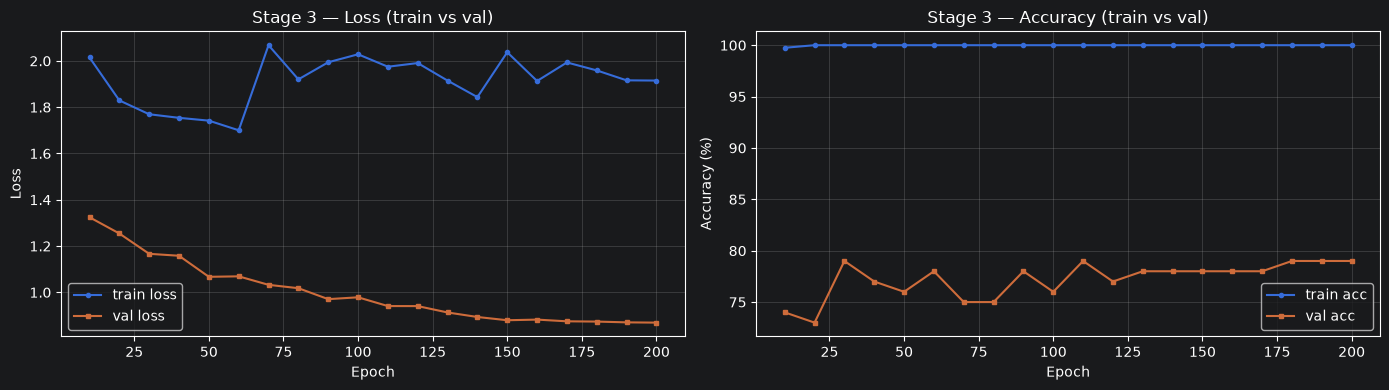

In [12]:
# ================================================================
# Inference: TTA + Tip-Adapterアンサンブル + 最終評価
# ================================================================

def tta_predict_cached(adapter, head, cache, idx, device=DEVICE, tip_cache=None, tip_w=0.0):
    """
    cache (test_cache) の identity + 全weak variants + 全strong variants を
    すべて使ってTTAを行う (キャッシュ済みなのでCLIP forwardは発生しない)。
    tip_cache が渡された場合は Tip-Adapter式キャッシュ分類器の予測もアンサンブルする。
    """
    head.eval()
    views = [cache.identity[idx]]
    for v in range(cache.weak.size(0)):
        views.append(cache.weak[v, idx])
    for v in range(cache.strong.size(0)):
        views.append(cache.strong[v, idx])

    probs = []
    with torch.no_grad():
        for feat_raw in views:
            feat = adapter.adapt(feat_raw.to(device))
            head_probs = F.softmax(head(feat), dim=-1)
            if tip_cache is not None and tip_w > 0:
                tip_logits = tip_cache.predict_logits(feat)
                tip_probs = F.softmax(tip_logits, dim=-1)
                combined = (1 - tip_w) * head_probs + tip_w * tip_probs
            else:
                combined = head_probs
            probs.append(combined)
    return torch.stack(probs).mean(0)


def evaluate_test_cached(adapter, head, cache, test_lbls, batch=256, label="",
                         device=DEVICE, tip_cache=None, tip_w=0.0):
    preds = []
    N = cache.identity.size(0)
    for i in tqdm(range(0, N, batch), desc=f"TTA [{label}]", position=0, leave=True):
        idx = torch.arange(i, min(i + batch, N))
        preds.append(tta_predict_cached(adapter, head, cache, idx, device=device,
                                        tip_cache=tip_cache, tip_w=tip_w).argmax(1).cpu())
    preds = torch.cat(preds)
    acc = (preds == test_lbls).float().mean().item()
    print(f"[{label}] ★ TEST Accuracy (final): {acc*100:.2f}%")
    return acc


print("\n=== Final Test Evaluation (1回のみ) ===")
print("  注: val は labeled 100枚 (1枚/クラス) しかなく統計的なブレが大きいため参考値。")
print("      最終判断は test (10000件) の精度を主指標とする。")
if history:
    best_ep = max(history, key=lambda h: h[4])
    print(f"  Best val_acc: {best_ep[4]*100:.1f}%  @ epoch {best_ep[0]} (参考値、アンサンブル seed0)")

# ---------- (v9/v10 新規) 分類器ヘッドアンサンブルのTTA ----------
# heads_ensemble / head_emas_ensemble は自己訓練ループの最終ラウンドで
# cfg.n_cls_ensemble 個学習されたヘッド群 (異なるseed、v10ではCV resplitで異なるtrain/val分割)。
# v10: CV resplitだとメンバーごとにTip-Adapterキャッシュも異なるため、
# tip_cache は単一ではなく「headと同じ長さのリスト」(tip_caches) で受け取れるようにする。
def tta_predict_cached_ensemble(adapter, heads, cache, idx, device=DEVICE, tip_caches=None, tip_w=0.0):
    """heads (複数のClassifierHead) のTTA予測確率を平均する (アンサンブル)。
    tip_caches: Noneなら使わない。単一のTipCacheなら全headで共有。リストならhead毎に対応するものを使う。"""
    if tip_caches is None:
        tip_list = [None] * len(heads)
    elif isinstance(tip_caches, (list, tuple)):
        tip_list = tip_caches
    else:
        tip_list = [tip_caches] * len(heads)
    probs_per_head = [tta_predict_cached(adapter, h, cache, idx, device=device,
                                         tip_cache=tc, tip_w=tip_w)
                       for h, tc in zip(heads, tip_list)]
    return torch.stack(probs_per_head).mean(0)

def evaluate_test_cached_ensemble(adapter, heads, cache, test_lbls, batch=256, label="",
                                  device=DEVICE, tip_caches=None, tip_w=0.0):
    preds = []
    N = cache.identity.size(0)
    for i in tqdm(range(0, N, batch), desc=f"TTA-ensemble [{label}]", position=0, leave=True):
        idx = torch.arange(i, min(i + batch, N))
        preds.append(tta_predict_cached_ensemble(adapter, heads, cache, idx, device=device,
                                                  tip_caches=tip_caches, tip_w=tip_w).argmax(1).cpu())
    preds = torch.cat(preds)
    acc = (preds == test_lbls).float().mean().item()
    print(f"[{label}] ★ TEST Accuracy (final): {acc*100:.2f}%")
    return acc

# 単一head (アンサンブルのseed0) の参考指標 (旧バージョンとの比較・アブレーション用)
acc_final     = evaluate_test_cached(adapter, head, test_cache, test_lbls, label="Head (single, seed0)")
acc_ema       = evaluate_test_cached(adapter, head_ema, test_cache, test_lbls, label="Head (EMA, single, seed0)")
acc_final_tip = evaluate_test_cached(adapter, head, test_cache, test_lbls, label="Head+Tip-Adapter (single, seed0)",
                                     tip_cache=tip_cache, tip_w=cfg.tip_ensemble_w)

# ★ 本命: 分類器ヘッドアンサンブル(n_cls_ensemble本, 自己訓練ループ後) + Tip-Adapter + TTA
# v10: tip_caches_ensemble はCV resplit時はメンバーごとに異なるTipCacheのリスト。
acc_ens         = evaluate_test_cached_ensemble(adapter, heads_ensemble, test_cache, test_lbls,
                                                label=f"Ensemble x{len(heads_ensemble)} (final heads)")
acc_ens_ema     = evaluate_test_cached_ensemble(adapter, head_emas_ensemble, test_cache, test_lbls,
                                                label=f"Ensemble x{len(head_emas_ensemble)} (EMA heads)")
acc_ens_tip     = evaluate_test_cached_ensemble(adapter, heads_ensemble, test_cache, test_lbls,
                                                label=f"★ Ensemble x{len(heads_ensemble)} + Tip-Adapter (final heads)",
                                                tip_caches=tip_caches_ensemble, tip_w=cfg.tip_ensemble_w)
acc_ens_ema_tip = evaluate_test_cached_ensemble(adapter, head_emas_ensemble, test_cache, test_lbls,
                                                label=f"★ Ensemble x{len(head_emas_ensemble)} + Tip-Adapter (EMA heads)",
                                                tip_caches=tip_caches_ensemble, tip_w=cfg.tip_ensemble_w)

results = [("single-final(seed0)", acc_final), ("single-EMA(seed0)", acc_ema),
          ("single-final+tip(seed0)", acc_final_tip),
          ("ensemble-final", acc_ens), ("ensemble-EMA", acc_ens_ema),
          ("ensemble-final+tip", acc_ens_tip), ("ensemble-EMA+tip", acc_ens_ema_tip)]
best_name, best_acc = max(results, key=lambda x: x[1])
print(f"\n  => test精度が最も高いのは: {best_name} ({best_acc*100:.2f}%)")
print(f"  => この {best_acc*100:.2f}% を Proposed (v9) の最終報告値として使う。")
print(f"  => (参考) アンサンブルなしの単一head最良値: {max(acc_final, acc_ema, acc_final_tip)*100:.2f}% "
      f"-> アンサンブル化による純増分の目安になる。")

# 学習曲線プロット
try:
    import matplotlib.pyplot as plt
    if history:
        eps        = [h[0] for h in history]
        train_ls   = [h[1] for h in history]
        val_ls     = [h[2] for h in history]
        train_accs = [h[3]*100 for h in history]
        val_accs   = [h[4]*100 for h in history]

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        axes[0].plot(eps, train_ls, label="train loss", marker="o", ms=3)
        axes[0].plot(eps, val_ls,   label="val loss",   marker="s", ms=3)
        axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
        axes[0].set_title("Stage 3 — Loss (train vs val)")
        axes[0].legend(); axes[0].grid(alpha=0.3)

        axes[1].plot(eps, train_accs, label="train acc", marker="o", ms=3)
        axes[1].plot(eps, val_accs,   label="val acc",   marker="s", ms=3)
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
        axes[1].set_title("Stage 3 — Accuracy (train vs val)")
        axes[1].legend(); axes[1].grid(alpha=0.3)

        plt.tight_layout(); plt.show()
except ImportError:
    pass


## 比較用 Baseline (簡易, 厳密なablationではない)

In [13]:
# ================================================================
# 比較用 Baseline (v4: SimpleCNN -> pretrained ResNet-50 fine-tune)
# ----------------------------------------------------------------
#   (1) baseline_resnet50   : ImageNet pretrained ResNet-50 を labeled 500枚で
#                              fine-tune。研究上の公平な比較対象として、
#                              事前学習あり・ラベルのみ・半教師なし手法なし、
#                              という条件を揃える。
#                              (v3のSimpleCNNより強いbaselineで、提案手法の
#                               優位性をより説得力ある形で示す)
#   (2) clip_supervised_only: CLIP+Adapter特徴 + labeled 500枚のみ
#                              (疑似ラベル・mixupなし。CLIPの素の効果のみ測る)
# ================================================================

def train_baseline_resnet50(cfg, lx_train, ly_train, lx_val, ly_val,
                            test_imgs, test_lbls, epochs=100, device=DEVICE):
    """
    pretrained ResNet-50 を labeled 500枚でfine-tune。
    入力は 224x224 (CLIPと同じ解像度) をそのまま使う。
    最終FC層のみを学習させる linear probe と、全層を低LRで学習する
    full fine-tune の2段階で行う (先にlinear probe -> 次にfull ft)。
    """
    import torchvision.models as tvm

    # ImageNet 正規化 (ResNet-50は ImageNet mean/std を期待する)
    imagenet_mean = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1)
    imagenet_std  = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1)

    def normalize_imagenet(x):
        return (x.float() - imagenet_mean) / imagenet_std

    # 画像テンソルはすでに 224x224 (CLIP解像度と同じ)。そのまま使う。
    lx_t_norm = normalize_imagenet(lx_train)
    lx_v_norm = normalize_imagenet(lx_val)

    model = tvm.resnet50(weights=tvm.ResNet50_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, cfg.n_classes)
    model = model.to(device)

    ce = nn.CrossEntropyLoss()
    loader_t = DataLoader(TensorDataset(lx_t_norm, ly_train), batch_size=32,
                          shuffle=True, num_workers=0)

    # --- Phase 1: Linear probe (FCのみ, 30 epoch) ---
    for name, p in model.named_parameters():
        p.requires_grad_("fc" in name)
    opt1 = torch.optim.Adam(model.fc.parameters(), lr=1e-3)
    for epoch in range(30):
        model.train()
        for x, y in loader_t:
            x, y = x.to(device), y.to(device)
            opt1.zero_grad(); ce(model(x), y).backward(); opt1.step()

    # --- Phase 2: Full fine-tune (全層, 低LR, 残り epochs) ---
    for p in model.parameters():
        p.requires_grad_(True)
    opt2 = torch.optim.AdamW([
        {"params": [p for n,p in model.named_parameters() if "fc" not in n], "lr": 1e-4},
        {"params": model.fc.parameters(), "lr": 1e-3},
    ], weight_decay=1e-4)
    sched2 = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, epochs - 30)
    best_acc = 0.0
    best_val_loss = float("inf")
    best_state = None
    for epoch in range(epochs - 30):
        model.train()
        for x, y in loader_t:
            x, y = x.to(device), y.to(device)
            opt2.zero_grad(); ce(model(x), y).backward(); opt2.step()
        sched2.step()

        # v8修正: 旧版は「最終epochのモデル」をそのままtest評価に使っていたため、
        # val_accがピークを過ぎて劣化した状態で測定されるバグがあった。
        # 毎epoch val_loss を計算し、最良時点のstate_dictを保持・復元する。
        model.eval()
        with torch.no_grad():
            val_logits = model(lx_v_norm.to(device))
            val_loss = ce(val_logits, ly_val.to(device)).item()
            acc = (val_logits.argmax(1).cpu() == ly_val).float().mean().item()
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
        if (epoch + 1) % 20 == 0:
            best_acc = max(best_acc, acc)
            tqdm.write(f"[ResNet-50 FT ep {epoch+31}] val_acc={acc*100:.1f}%  val_loss={val_loss:.4f}  (best_val_loss={best_val_loss:.4f})")

    if best_state is not None:
        model.load_state_dict(best_state)   # ★ v8修正: ベストモデルを復元してtest評価
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(test_imgs), 128):
            x = normalize_imagenet(test_imgs[i:i+128]).to(device)
            preds.append(model(x).argmax(1).cpu())
    preds = torch.cat(preds)
    test_acc = (preds == test_lbls).float().mean().item()
    print(f"[Baseline ResNet-50 FT] ★ TEST Accuracy: {test_acc*100:.2f}%")
    return test_acc


def train_clip_supervised_only(cfg, adapter, train_cache, val_cache, test_cache,
                               ly_train, ly_val, test_lbls, N_l, epochs=100):
    """CLIP+Adapter特徴のみ、labeled 500枚のみで学習 (疑似ラベル・mixupなし)。
    キャッシュ済み特徴を使うため CLIP forward は発生しない。

    v8修正 (重要バグ): 旧版はepoch数固定(100)で学習しきった「最終epochのhead」を
    そのままtest評価していた。実測ログでは
        ep80  val_acc=64.0%
        ep100 val_acc=62.0%  <- このモデルでtest評価していた (劣化後)
    となっており、ピークを過ぎたモデルで測定する不公正な比較になっていた
    (この結果、supervised-onlyがCLIP ViT-B/32のzero-shot性能(文献値65%前後)
    すら下回る53.11%という不自然に低い値になっていた可能性が高い)。
    v8では毎epoch val_loss を計算し、最良時点のstate_dictを保持・復元してから
    test評価する。val_acc(100枚しかなく1%刻み)よりval_lossの方が連続値で
    ノイズが少なく、ベスト判定の基準として安定している。
    また weight_decay も Stage3分類器(1e-2)と揃え、AdamW+cosine schedulerに統一し、
    Proposedとの比較条件をできるだけ揃えた。
    """
    head = ClassifierHead(cfg).to(cfg.device)
    opt   = torch.optim.AdamW(head.parameters(), lr=1e-3, weight_decay=1e-2)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    ce    = nn.CrossEntropyLoss(label_smoothing=cfg.label_smoothing)

    with torch.no_grad():
        feat_train = adapter.adapt(train_cache.identity[:N_l].to(cfg.device)).cpu()
        feat_val   = adapter.adapt(val_cache.identity.to(cfg.device)).cpu()

    loader = DataLoader(TensorDataset(feat_train, ly_train), batch_size=64, shuffle=True)

    best_val_loss = float("inf")
    best_state = copy.deepcopy(head.state_dict())
    for epoch in range(epochs):
        head.train()
        for f, y in loader:
            f, y = f.to(cfg.device), y.to(cfg.device)
            opt.zero_grad(); ce(head(f), y).backward(); opt.step()
        sched.step()

        head.eval()
        with torch.no_grad():
            val_logits = head(feat_val.to(cfg.device))
            val_loss = F.cross_entropy(val_logits, ly_val.to(cfg.device)).item()
            val_acc  = (val_logits.argmax(1).cpu() == ly_val).float().mean().item()
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(head.state_dict())
        if (epoch + 1) % 20 == 0:
            tqdm.write(f"[CLIP supervised-only ep {epoch+1}] val_acc={val_acc*100:.1f}%  "
                       f"val_loss={val_loss:.4f}  (best_val_loss={best_val_loss:.4f})")

    head.load_state_dict(best_state)   # ★ v8修正: ベストモデルを復元してtest評価
    head.eval()
    with torch.no_grad():
        feat_test = adapter.adapt(test_cache.identity.to(cfg.device))
        preds = head(feat_test).argmax(1).cpu()
    test_acc = (preds == test_lbls).float().mean().item()
    print(f"[CLIP supervised-only] ★ TEST Accuracy: {test_acc*100:.2f}%  (best-val-loss checkpoint)")
    return test_acc


print("\n=== Reference comparisons ===")
acc_resnet50  = train_baseline_resnet50(cfg, lx_train, ly_train, lx_val, ly_val,
                                        test_imgs, test_lbls)
acc_clip_only = train_clip_supervised_only(cfg, adapter, train_cache, val_cache, test_cache,
                                           ly_train, ly_val, test_lbls, N_l_global)

# ---------- (v9.1 新規, 必要最低限のablation) ----------
# (a) Adapterの効果切り分け: Adapterを通さない「生のCLIP特徴」でsupervised-onlyを学習。
#     既存の train_clip_supervised_only を、何もしない恒等Adapterで呼ぶだけ
#     (関数自体は1行も変更しない最小実装)。
class _IdentityAdapter:
    """v9.1: Adapterの効果を見るための恒等関数 (何も変換しない)。"""
    def adapt(self, x):
        return x

print("\n--- (v9.1) Adapter ablation: 生CLIP特徴 vs Adapter適用後 ---")
acc_clip_only_raw = train_clip_supervised_only(
    cfg, _IdentityAdapter(), train_cache, val_cache, test_cache,
    ly_train, ly_val, test_lbls, N_l_global)

# (b) 参考: CLIP zero-shot (学習一切無し、n=0の基準点)。計算コストはほぼゼロ。
with torch.no_grad():
    zs_text_feat = get_zeroshot_text_features(cfg, _clip_full)
    zs_img_feat  = F.normalize(test_cache.identity, dim=-1).to(cfg.device)
    zs_preds = (100.0 * zs_img_feat @ zs_text_feat.to(cfg.device).T).argmax(1).cpu()
acc_zeroshot = (zs_preds == test_lbls).float().mean().item()
print(f"[CLIP zero-shot (ラベル0枚, 学習無し)] ★ TEST Accuracy: {acc_zeroshot*100:.2f}%")

acc_proposed_head    = evaluate_test_cached(adapter, head_ema, test_cache, test_lbls,
                                            label="Proposed, Head-only (EMA)")
acc_proposed_full    = evaluate_test_cached(adapter, head_ema, test_cache, test_lbls,
                                            label="Proposed, Head+Tip-Adapter (EMA)",
                                            tip_cache=tip_cache, tip_w=cfg.tip_ensemble_w)
acc_proposed = max(acc_proposed_head, acc_proposed_full)

print("\n=== Summary ===")
print(f"  CLIP zero-shot (ラベル0枚、参考点)                           : {acc_zeroshot*100:.2f}%")
print(f"  Baseline: pretrained ResNet-50 fine-tune (500 labels)        : {acc_resnet50*100:.2f}%")
print(f"  CLIP {cfg.clip_model_name} (生特徴, Adapter無し) supervised-only         : {acc_clip_only_raw*100:.2f}%")
print(f"  CLIP {cfg.clip_model_name} + Adapter, supervised-only (500 labels)       : {acc_clip_only*100:.2f}%")
print(f"  Proposed, Head-only (GCN+Proto-CLIP+CGMatch+mixup)           : {acc_proposed_head*100:.2f}%")
print(f"  Proposed, Head+Tip-Adapter ensemble                          : {acc_proposed_full*100:.2f}%")
print(f"  --------------------------------------------------------------")
print(f"  Proposed vs supervised-only(Adapter有) の差: +{(acc_proposed - acc_clip_only)*100:.2f}pt")
print(f"  Adapterの寄与 (Adapter有 - Adapter無)        : {(acc_clip_only - acc_clip_only_raw)*100:+.2f}pt"
      f"  (負の場合、Adapterが特徴空間を悪化させている可能性)")
print(f"  supervised-only(Adapter無) vs zero-shotの差  : {(acc_clip_only_raw - acc_zeroshot)*100:+.2f}pt"
      f"  (負の場合、5-shot学習がzero-shotより劣化=要調査)")



=== Reference comparisons ===
[ResNet-50 FT ep 50] val_acc=44.0%  val_loss=2.4256  (best_val_loss=2.4256)
[ResNet-50 FT ep 70] val_acc=45.0%  val_loss=2.4081  (best_val_loss=2.3974)
[ResNet-50 FT ep 90] val_acc=45.0%  val_loss=2.4070  (best_val_loss=2.3888)
[Baseline ResNet-50 FT] ★ TEST Accuracy: 36.33%
[CLIP supervised-only ep 20] val_acc=70.0%  val_loss=1.3511  (best_val_loss=1.3511)
[CLIP supervised-only ep 40] val_acc=71.0%  val_loss=1.3933  (best_val_loss=1.3511)
[CLIP supervised-only ep 60] val_acc=70.0%  val_loss=1.4154  (best_val_loss=1.3511)
[CLIP supervised-only ep 80] val_acc=70.0%  val_loss=1.4284  (best_val_loss=1.3511)
[CLIP supervised-only ep 100] val_acc=70.0%  val_loss=1.4265  (best_val_loss=1.3511)
[CLIP supervised-only] ★ TEST Accuracy: 68.90%  (best-val-loss checkpoint)

--- (v9.1) Adapter ablation: 生CLIP特徴 vs Adapter適用後 ---
[CLIP supervised-only ep 20] val_acc=71.0%  val_loss=1.3361  (best_val_loss=1.3361)
[CLIP supervised-only ep 40] val_acc=73.0%  val_loss=1.38

TTA [Proposed, Head-only (EMA)]:   0%|          | 0/40 [00:00<?, ?it/s]

[Proposed, Head-only (EMA)] ★ TEST Accuracy (final): 79.42%


TTA [Proposed, Head+Tip-Adapter (EMA)]:   0%|          | 0/40 [00:00<?, ?it/s]

[Proposed, Head+Tip-Adapter (EMA)] ★ TEST Accuracy (final): 79.21%

=== Summary ===
  CLIP zero-shot (ラベル0枚、参考点)                           : 75.22%
  Baseline: pretrained ResNet-50 fine-tune (500 labels)        : 36.33%
  CLIP ViT-L-14 (生特徴, Adapter無し) supervised-only         : 68.40%
  CLIP ViT-L-14 + Adapter, supervised-only (500 labels)       : 68.90%
  Proposed, Head-only (GCN+Proto-CLIP+CGMatch+mixup)           : 79.42%
  Proposed, Head+Tip-Adapter ensemble                          : 79.21%
  --------------------------------------------------------------
  Proposed vs supervised-only(Adapter有) の差: +10.52pt
  Adapterの寄与 (Adapter有 - Adapter無)        : +0.50pt  (負の場合、Adapterが特徴空間を悪化させている可能性)
  supervised-only(Adapter無) vs zero-shotの差  : -6.82pt  (負の場合、5-shot学習がzero-shotより劣化=要調査)
